In [4]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = Path("../music_artist_insights.duckdb")

con = duckdb.connect(
    str(DB_PATH),
    read_only=True
)

print("Connected to DuckDB")

Connected to DuckDB


In [5]:
release_yearly = con.execute("""
    SELECT
        artist_name,
        release_year,
        total_releases,
        core_releases,
        singles,
        albums,
        eps,
        remixes,
        compilations,
        dj_mixes,
        live_releases,
        comparable_ytd_releases,
        comparable_ytd_core_releases,
        dataset_through_date
    FROM gold_release_metrics
    ORDER BY artist_name, release_year
""").fetchdf()

release_yearly

,artist_name,release_year,total_releases,core_releases,singles,albums,eps,remixes,compilations,dj_mixes,live_releases,comparable_ytd_releases,comparable_ytd_core_releases,dataset_through_date
0,ARTBAT,2015,3,3,2,0,1,0,0,0,0,0,0,2026-09-04
1,ARTBAT,2016,3,3,3,0,0,0,0,0,0,3,3,2026-09-04
2,ARTBAT,2017,4,4,2,0,2,0,0,0,0,3,3,2026-09-04
3,ARTBAT,2018,2,2,1,0,1,0,0,0,0,1,1,2026-09-04
4,ARTBAT,2019,5,5,4,1,0,0,0,0,0,4,4,2026-09-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,Tiësto,2022,18,8,16,0,2,10,0,0,0,7,2,2026-07-17
177,Tiësto,2023,21,10,18,2,1,10,0,1,0,12,5,2026-07-17
178,Tiësto,2024,19,17,18,0,1,2,0,0,0,10,9,2026-07-17
179,Tiësto,2025,17,12,14,0,3,5,0,0,0,12,10,2026-07-17


In [6]:
artist_baselines = (
    release_yearly[
        release_yearly["release_year"] < 2026
    ]
    .groupby("artist_name")
    .agg(
        historical_avg_releases=("total_releases", "mean"),
        historical_median_releases=("total_releases", "median"),
        historical_avg_core_releases=("core_releases", "mean"),
        active_years=("release_year", "nunique"),
    )
    .reset_index()
)

artist_baselines.round(1)

,artist_name,historical_avg_releases,historical_median_releases,historical_avg_core_releases,active_years
0,ARTBAT,4.8,4.0,4.3,11
1,Above & Beyond,9.8,8.5,5.0,24
2,Armin van Buuren,19.1,20.5,9.6,28
3,Ben Gold,2.9,3.0,2.6,17
4,Ferry Corsten,5.8,5.0,3.8,27
5,Hardwell,11.2,10.0,7.4,21
6,Hypaton,2.8,2.0,2.2,4
7,Maddix,8.3,9.0,7.0,11
8,Tiësto,10.6,10.0,6.1,30


In [7]:
current = (
    release_yearly[
        release_yearly["release_year"] == 2026
    ][
        [
            "artist_name",
            "comparable_ytd_releases",
            "comparable_ytd_core_releases",
            "dataset_through_date",
        ]
    ]
    .copy()
)

context = current.merge(
    artist_baselines,
    on="artist_name",
    how="left"
)

context["ytd_vs_historical_avg_pct"] = (
    (
        context["comparable_ytd_releases"]
        / context["historical_avg_releases"]
    )
    - 1
) * 100

context.round(1)

/var/folders/n3/m2px247567bd0zrky2q6tmlw0000gn/T/ipykernel_19699/3765762596.py:29: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  context.round(1)


,artist_name,comparable_ytd_releases,comparable_ytd_core_releases,dataset_through_date,historical_avg_releases,historical_median_releases,historical_avg_core_releases,active_years,ytd_vs_historical_avg_pct
0,ARTBAT,4,3,2026-09-04,4.8,4.0,4.3,11,-17.0
1,Above & Beyond,11,4,2026-09-14,9.8,8.5,5.0,24,12.3
2,Armin van Buuren,28,18,2026-09-25,19.1,20.5,9.6,28,46.5
3,Ferry Corsten,6,5,2026-08-14,5.8,5.0,3.8,27,3.8
4,Hardwell,16,10,2026-09-04,11.2,10.0,7.4,21,42.4
5,Hypaton,3,3,2026-09-11,2.8,2.0,2.2,4,9.1
6,Maddix,8,8,2026-07-24,8.3,9.0,7.0,11,-3.3
7,Tiësto,3,3,2026-07-17,10.6,10.0,6.1,30,-71.6


In [8]:
catalogue = con.execute("""
    SELECT
        artist_name,
        first_release_date,
        primary_type,
        is_remix,
        is_compilation,
        is_live,
        is_dj_mix
    FROM release_catalogue
""").fetchdf()

catalogue["first_release_date"] = pd.to_datetime(
    catalogue["first_release_date"]
)

catalogue.head()

,artist_name,first_release_date,primary_type,is_remix,is_compilation,is_live,is_dj_mix
0,Above & Beyond,2002-05-04,Single,True,False,False,False
1,Above & Beyond,2002-11-04,Single,False,False,False,False
2,Above & Beyond,2003-01-04,Single,True,False,False,False
3,Above & Beyond,2003-04-28,EP,False,False,False,False
4,Above & Beyond,2003-10-13,Album,False,True,False,True


In [9]:
CUTOFF_MONTH = 9
CUTOFF_DAY = 29

catalogue["release_year"] = (
    catalogue["first_release_date"].dt.year
)

catalogue["within_comparable_period"] = (
    (catalogue["first_release_date"].dt.month < CUTOFF_MONTH)
    |
    (
        (catalogue["first_release_date"].dt.month == CUTOFF_MONTH)
        &
        (catalogue["first_release_date"].dt.day <= CUTOFF_DAY)
    )
)

comparable = (
    catalogue[
        catalogue["within_comparable_period"]
    ]
    .groupby(
        ["artist_name", "release_year"]
    )
    .size()
    .reset_index(name="comparable_releases")
)

comparable.tail(12)

,artist_name,release_year,comparable_releases
167,Tiësto,2015,11
168,Tiësto,2016,10
169,Tiësto,2017,8
170,Tiësto,2018,14
171,Tiësto,2019,14
172,Tiësto,2020,13
173,Tiësto,2021,7
174,Tiësto,2022,10
175,Tiësto,2023,14
176,Tiësto,2024,15


In [10]:
recent_baseline = (
    comparable[
        comparable["release_year"].between(
            2021,
            2025
        )
    ]
    .groupby("artist_name")
    .agg(
        avg_comparable_releases_5y=(
            "comparable_releases",
            "mean"
        ),
        median_comparable_releases_5y=(
            "comparable_releases",
            "median"
        )
    )
    .reset_index()
)

current_2026 = (
    comparable[
        comparable["release_year"] == 2026
    ][
        [
            "artist_name",
            "comparable_releases"
        ]
    ]
    .rename(
        columns={
            "comparable_releases":
            "releases_2026_ytd"
        }
    )
)

momentum_context = current_2026.merge(
    recent_baseline,
    on="artist_name",
    how="left"
)

momentum_context["vs_5y_avg_pct"] = (
    (
        momentum_context["releases_2026_ytd"]
        / momentum_context["avg_comparable_releases_5y"]
    )
    - 1
) * 100

momentum_context.round(1)

,artist_name,releases_2026_ytd,avg_comparable_releases_5y,median_comparable_releases_5y,vs_5y_avg_pct
0,ARTBAT,4,4.8,4.0,-16.7
1,Above & Beyond,11,9.6,9.0,14.6
2,Armin van Buuren,28,22.4,22.0,25.0
3,Ferry Corsten,6,2.8,3.0,114.3
4,Hardwell,16,8.2,7.0,95.1
5,Hypaton,3,2.2,1.5,33.3
6,Maddix,8,7.0,7.0,14.3
7,Tiësto,3,12.2,14.0,-75.4


In [11]:
catalogue["is_core"] = (
    ~catalogue["is_remix"]
    & ~catalogue["is_compilation"]
    & ~catalogue["is_live"]
    & ~catalogue["is_dj_mix"]
)

comparable_detail = (
    catalogue[
        catalogue["within_comparable_period"]
    ]
    .groupby(
        ["artist_name", "release_year"]
    )
    .agg(
        total_releases=(
            "first_release_date",
            "size"
        ),
        core_releases=(
            "is_core",
            "sum"
        )
    )
    .reset_index()
)

comparable_detail["broader_releases"] = (
    comparable_detail["total_releases"]
    - comparable_detail["core_releases"]
)

comparable_detail["core_share_pct"] = (
    comparable_detail["core_releases"]
    / comparable_detail["total_releases"]
    * 100
)

comparable_detail[
    comparable_detail["release_year"] >= 2021
].round(1)

,artist_name,release_year,total_releases,core_releases,broader_releases,core_share_pct
6,ARTBAT,2021,2,1,1,50.0
7,ARTBAT,2022,4,4,0,100.0
8,ARTBAT,2023,4,4,0,100.0
9,ARTBAT,2024,7,6,1,85.7
10,ARTBAT,2025,7,7,0,100.0
11,ARTBAT,2026,4,3,1,75.0
31,Above & Beyond,2021,9,3,6,33.3
32,Above & Beyond,2022,15,6,9,40.0
33,Above & Beyond,2023,4,4,0,100.0
34,Above & Beyond,2024,8,3,5,37.5


In [12]:
audience = con.execute("""
    SELECT
        artist_name,
        snapshot_date,
        listeners,
        playcount,
        playcount_per_listener,
        previous_listeners,
        listener_change,
        listener_growth_pct,
        previous_playcount,
        playcount_change,
        playcount_growth_pct
    FROM gold_lastfm_audience_metrics
    ORDER BY artist_name, snapshot_date
""").fetchdf()

audience

,artist_name,snapshot_date,listeners,playcount,playcount_per_listener,previous_listeners,listener_change,listener_growth_pct,previous_playcount,playcount_change,playcount_growth_pct
0,ARTBAT,2026-09-30,180758,2011740,11.13,<NA>,<NA>,NaN,<NA>,<NA>,NaN
1,Above & Beyond,2026-09-30,866769,26743979,30.85,<NA>,<NA>,NaN,<NA>,<NA>,NaN
2,Armin van Buuren,2026-09-27,1787610,62506007,34.97,<NA>,<NA>,NaN,<NA>,<NA>,NaN
3,Armin van Buuren,2026-09-29,1787889,62513382,34.96,1787610,279,0.02,62506007,7375,0.01
4,Ben Gold,2026-09-30,92324,1247731,13.51,<NA>,<NA>,NaN,<NA>,<NA>,NaN
5,Ferry Corsten,2026-09-30,721033,10701498,14.84,<NA>,<NA>,NaN,<NA>,<NA>,NaN
6,Hardwell,2026-09-30,777077,17085445,21.99,<NA>,<NA>,NaN,<NA>,<NA>,NaN
7,Hypaton,2026-09-30,201348,1237204,6.14,<NA>,<NA>,NaN,<NA>,<NA>,NaN
8,Maddix,2026-09-30,251672,2914685,11.58,<NA>,<NA>,NaN,<NA>,<NA>,NaN
9,Tiësto,2026-09-29,2823523,71266760,25.24,<NA>,<NA>,NaN,<NA>,<NA>,NaN


In [13]:
latest_audience = (
    audience
    .sort_values("snapshot_date")
    .groupby("artist_name")
    .tail(1)
    [
        [
            "artist_name",
            "snapshot_date",
            "listeners",
            "playcount",
            "playcount_per_listener"
        ]
    ]
    .reset_index(drop=True)
)

latest_audience

,artist_name,snapshot_date,listeners,playcount,playcount_per_listener
0,Armin van Buuren,2026-09-29,1787889,62513382,34.96
1,Tiësto,2026-09-29,2823523,71266760,25.24
2,ARTBAT,2026-09-30,180758,2011740,11.13
3,Above & Beyond,2026-09-30,866769,26743979,30.85
4,Ben Gold,2026-09-30,92324,1247731,13.51
5,Ferry Corsten,2026-09-30,721033,10701498,14.84
6,Hardwell,2026-09-30,777077,17085445,21.99
7,Hypaton,2026-09-30,201348,1237204,6.14
8,Maddix,2026-09-30,251672,2914685,11.58


In [14]:
import duckdb
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

con = duckdb.connect("../music_artist_insights.duckdb", read_only=True)

cohort = con.execute("""
    SELECT *
    FROM gold_cohort_comparison
    ORDER BY
        CASE context_role
            WHEN 'anchor' THEN 1
            WHEN 'close_context' THEN 2
            WHEN 'growth_context' THEN 3
            WHEN 'legacy_context' THEN 4
            WHEN 'crossover_context' THEN 5
            WHEN 'adjacent_context' THEN 6
            ELSE 7
        END,
        artist_name
""").fetchdf()

cohort

,artist_name,context_role,context_scope,first_release_date,latest_release_date,career_span_years,total_releases,albums,singles,eps,spotify_snapshot_date,spotify_monthly_listeners,spotify_followers,mbid,lastfm_snapshot_date,lastfm_listeners,lastfm_playcount,audience_intensity
0,Armin van Buuren,anchor,close_context,1996-01-01,2026-09-25,30,563,206,320,37,2026-09-30,15055533,4784676,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,2026-09-29,1787889,62513382,34.96
1,Above & Beyond,close_context,close_context,2002-05-04,2026-09-14,24,246,61,175,10,2026-09-30,2109959,900152,370bd5a3-4abf-4356-8576-3a8fc0c11d65,2026-09-30,866769,26743979,30.85
2,Ben Gold,close_context,close_context,2007-08-27,2025-05-16,18,50,9,37,4,2026-09-30,215644,66254,f338cde2-7cc4-49e0-83e4-a0ac1a3b6d46,2026-09-30,92324,1247731,13.51
3,Maddix,close_context,close_context,2015-05-30,2026-07-24,11,99,4,93,2,2026-09-30,4651776,254996,0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8,2026-09-30,251672,2914685,11.58
4,Hypaton,growth_context,candidate,2022-08-12,2026-09-11,4,14,0,13,1,2026-09-30,6267536,120518,a6ef06e3-98f4-453e-9978-f3eb4e70cf32,2026-09-30,201348,1237204,6.14
5,Ferry Corsten,legacy_context,close_context,1999-01-01,2026-08-14,27,162,52,99,11,2026-09-30,1392550,307454,47347cb8-ac34-4916-84b6-d85d4e5e5384,2026-09-30,721033,10701498,14.84
6,Hardwell,crossover_context,broad_context,2003-01-01,2026-09-04,23,252,41,195,16,2026-09-30,5653979,3646121,170d6637-36e0-49dd-a225-c4fd5b77a285,2026-09-30,777077,17085445,21.99
7,Tiësto,crossover_context,broad_context,1996-01-01,2026-07-17,30,320,53,251,16,2026-09-30,33124303,8509111,aabb1d9f-be12-45b3-a84d-a1fc3e8181fd,2026-09-29,2823523,71266760,25.24
8,ARTBAT,adjacent_context,broad_context,2015-09-14,2026-09-04,11,57,1,52,4,2026-09-30,5418283,653859,f812b317-6cd1-4083-9798-b6a4e5f97400,2026-09-30,180758,2011740,11.13


In [15]:
catalogue_context = con.execute("""
WITH cutoffs AS (
    SELECT
        artist_name,
        dataset_through_date,
        MONTH(dataset_through_date) AS cutoff_month,
        DAY(dataset_through_date) AS cutoff_day
    FROM gold_release_metrics
    WHERE release_year = 2026
),

historical_ytd AS (
    SELECT
        r.artist_name,
        YEAR(r.first_release_date) AS release_year,
        COUNT(*) AS releases_ytd,
        SUM(
            CASE
                WHEN NOT r.is_compilation
                 AND NOT r.is_remix
                 AND NOT r.is_live
                 AND NOT r.is_dj_mix
                THEN 1
                ELSE 0
            END
        ) AS core_ytd
    FROM release_catalogue r
    JOIN cutoffs c
        ON r.artist_name = c.artist_name
    WHERE YEAR(r.first_release_date) BETWEEN 2021 AND 2025
      AND (
            MONTH(r.first_release_date) < c.cutoff_month
            OR (
                MONTH(r.first_release_date) = c.cutoff_month
                AND DAY(r.first_release_date) <= c.cutoff_day
            )
          )
    GROUP BY
        r.artist_name,
        YEAR(r.first_release_date)
),

baseline AS (
    SELECT
        artist_name,
        ROUND(AVG(releases_ytd), 1) AS historical_ytd_avg,
        MEDIAN(releases_ytd) AS historical_ytd_median,
        ROUND(AVG(core_ytd), 1) AS historical_core_ytd_avg
    FROM historical_ytd
    GROUP BY artist_name
)

SELECT
    r.artist_name,
    r.dataset_through_date,
    r.total_releases AS releases_2026_ytd,
    r.core_releases AS core_releases_2026_ytd,
    r.singles AS singles_2026_ytd,
    r.albums AS albums_2026_ytd,
    r.eps AS eps_2026_ytd,
    r.remixes AS remixes_2026_ytd,
    r.compilations AS compilations_2026_ytd,
    r.dj_mixes AS dj_mixes_2026_ytd,
    b.historical_ytd_avg,
    b.historical_ytd_median,
    b.historical_core_ytd_avg,

    ROUND(
        (r.total_releases / NULLIF(b.historical_ytd_avg, 0) - 1) * 100,
        1
    ) AS release_deviation_pct,

    ROUND(
        (r.core_releases / NULLIF(b.historical_core_ytd_avg, 0) - 1) * 100,
        1
    ) AS core_deviation_pct

FROM gold_release_metrics r

LEFT JOIN baseline b
    ON r.artist_name = b.artist_name

WHERE r.release_year = 2026
ORDER BY release_deviation_pct DESC
""").fetchdf()

catalogue_context

,artist_name,dataset_through_date,releases_2026_ytd,core_releases_2026_ytd,singles_2026_ytd,albums_2026_ytd,eps_2026_ytd,remixes_2026_ytd,compilations_2026_ytd,dj_mixes_2026_ytd,historical_ytd_avg,historical_ytd_median,historical_core_ytd_avg,release_deviation_pct,core_deviation_pct
0,Ferry Corsten,2026-08-14,6,5,5,0,1,1,0,0,2.0,2.0,1.8,200.0,177.8
1,Hardwell,2026-09-04,16,10,14,0,2,6,0,0,7.6,6.0,7.0,110.5,42.9
2,Maddix,2026-07-24,8,8,7,0,1,0,0,0,5.4,5.0,5.0,48.1,60.0
3,Hypaton,2026-09-11,3,3,3,0,0,0,0,0,2.3,1.5,2.3,30.4,30.4
4,Armin van Buuren,2026-09-25,28,18,22,4,2,6,2,2,22.2,22.0,16.4,26.1,9.8
5,Above & Beyond,2026-09-14,11,4,8,2,1,5,1,2,8.8,9.0,4.8,25.0,-16.7
6,ARTBAT,2026-09-04,4,3,4,0,0,1,0,0,4.6,4.0,4.2,-13.0,-28.6
7,Tiësto,2026-07-17,3,3,3,0,0,0,0,0,9.0,10.0,5.4,-66.7,-44.4


In [16]:
artist_context = cohort.merge(
    catalogue_context,
    on="artist_name",
    how="left"
)

artist_context

,artist_name,context_role,context_scope,first_release_date,latest_release_date,career_span_years,total_releases,albums,singles,eps,spotify_snapshot_date,spotify_monthly_listeners,spotify_followers,mbid,lastfm_snapshot_date,lastfm_listeners,lastfm_playcount,audience_intensity,dataset_through_date,releases_2026_ytd,core_releases_2026_ytd,singles_2026_ytd,albums_2026_ytd,eps_2026_ytd,remixes_2026_ytd,compilations_2026_ytd,dj_mixes_2026_ytd,historical_ytd_avg,historical_ytd_median,historical_core_ytd_avg,release_deviation_pct,core_deviation_pct
0,Armin van Buuren,anchor,close_context,1996-01-01,2026-09-25,30,563,206,320,37,2026-09-30,15055533,4784676,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,2026-09-29,1787889,62513382,34.96,2026-09-25,28.0,18.0,22.0,4.0,2.0,6.0,2.0,2.0,22.2,22.0,16.4,26.1,9.8
1,Above & Beyond,close_context,close_context,2002-05-04,2026-09-14,24,246,61,175,10,2026-09-30,2109959,900152,370bd5a3-4abf-4356-8576-3a8fc0c11d65,2026-09-30,866769,26743979,30.85,2026-09-14,11.0,4.0,8.0,2.0,1.0,5.0,1.0,2.0,8.8,9.0,4.8,25.0,-16.7
2,Ben Gold,close_context,close_context,2007-08-27,2025-05-16,18,50,9,37,4,2026-09-30,215644,66254,f338cde2-7cc4-49e0-83e4-a0ac1a3b6d46,2026-09-30,92324,1247731,13.51,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Maddix,close_context,close_context,2015-05-30,2026-07-24,11,99,4,93,2,2026-09-30,4651776,254996,0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8,2026-09-30,251672,2914685,11.58,2026-07-24,8.0,8.0,7.0,0.0,1.0,0.0,0.0,0.0,5.4,5.0,5.0,48.1,60.0
4,Hypaton,growth_context,candidate,2022-08-12,2026-09-11,4,14,0,13,1,2026-09-30,6267536,120518,a6ef06e3-98f4-453e-9978-f3eb4e70cf32,2026-09-30,201348,1237204,6.14,2026-09-11,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,2.3,1.5,2.3,30.4,30.4
5,Ferry Corsten,legacy_context,close_context,1999-01-01,2026-08-14,27,162,52,99,11,2026-09-30,1392550,307454,47347cb8-ac34-4916-84b6-d85d4e5e5384,2026-09-30,721033,10701498,14.84,2026-08-14,6.0,5.0,5.0,0.0,1.0,1.0,0.0,0.0,2.0,2.0,1.8,200.0,177.8
6,Hardwell,crossover_context,broad_context,2003-01-01,2026-09-04,23,252,41,195,16,2026-09-30,5653979,3646121,170d6637-36e0-49dd-a225-c4fd5b77a285,2026-09-30,777077,17085445,21.99,2026-09-04,16.0,10.0,14.0,0.0,2.0,6.0,0.0,0.0,7.6,6.0,7.0,110.5,42.9
7,Tiësto,crossover_context,broad_context,1996-01-01,2026-07-17,30,320,53,251,16,2026-09-30,33124303,8509111,aabb1d9f-be12-45b3-a84d-a1fc3e8181fd,2026-09-29,2823523,71266760,25.24,2026-07-17,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,9.0,10.0,5.4,-66.7,-44.4
8,ARTBAT,adjacent_context,broad_context,2015-09-14,2026-09-04,11,57,1,52,4,2026-09-30,5418283,653859,f812b317-6cd1-4083-9798-b6a4e5f97400,2026-09-30,180758,2011740,11.13,2026-09-04,4.0,3.0,4.0,0.0,0.0,1.0,0.0,0.0,4.6,4.0,4.2,-13.0,-28.6


In [17]:
artist_context[
    [
        "artist_name",
        "context_role",
        "spotify_monthly_listeners",
        "spotify_followers",
        "lastfm_listeners",
        "audience_intensity",
        "career_span_years",
        "total_releases",
        "releases_2026_ytd",
        "historical_ytd_avg",
        "release_deviation_pct",
        "core_releases_2026_ytd",
        "historical_core_ytd_avg",
        "core_deviation_pct",
    ]
]

,artist_name,context_role,spotify_monthly_listeners,spotify_followers,lastfm_listeners,audience_intensity,career_span_years,total_releases,releases_2026_ytd,historical_ytd_avg,release_deviation_pct,core_releases_2026_ytd,historical_core_ytd_avg,core_deviation_pct
0,Armin van Buuren,anchor,15055533,4784676,1787889,34.96,30,563,28.0,22.2,26.1,18.0,16.4,9.8
1,Above & Beyond,close_context,2109959,900152,866769,30.85,24,246,11.0,8.8,25.0,4.0,4.8,-16.7
2,Ben Gold,close_context,215644,66254,92324,13.51,18,50,NaN,NaN,NaN,NaN,NaN,NaN
3,Maddix,close_context,4651776,254996,251672,11.58,11,99,8.0,5.4,48.1,8.0,5.0,60.0
4,Hypaton,growth_context,6267536,120518,201348,6.14,4,14,3.0,2.3,30.4,3.0,2.3,30.4
5,Ferry Corsten,legacy_context,1392550,307454,721033,14.84,27,162,6.0,2.0,200.0,5.0,1.8,177.8
6,Hardwell,crossover_context,5653979,3646121,777077,21.99,23,252,16.0,7.6,110.5,10.0,7.0,42.9
7,Tiësto,crossover_context,33124303,8509111,2823523,25.24,30,320,3.0,9.0,-66.7,3.0,5.4,-44.4
8,ARTBAT,adjacent_context,5418283,653859,180758,11.13,11,57,4.0,4.6,-13.0,3.0,4.2,-28.6


In [18]:
analysis_view = artist_context[
    [
        "artist_name",
        "context_role",
        "spotify_monthly_listeners",
        "spotify_followers",
        "lastfm_listeners",
        "audience_intensity",
        "career_span_years",
        "total_releases",
        "releases_2026_ytd",
        "historical_ytd_avg",
        "release_deviation_pct",
        "core_deviation_pct",
    ]
].copy()

analysis_view["spotify_listener_share_pct"] = (
    analysis_view["spotify_monthly_listeners"]
    / analysis_view["spotify_monthly_listeners"].sum()
    * 100
).round(1)

analysis_view["spotify_to_lastfm_ratio"] = (
    analysis_view["spotify_monthly_listeners"]
    / analysis_view["lastfm_listeners"]
).round(1)

analysis_view[
    [
        "artist_name",
        "context_role",
        "spotify_monthly_listeners",
        "lastfm_listeners",
        "spotify_to_lastfm_ratio",
        "audience_intensity",
        "career_span_years",
        "total_releases",
        "release_deviation_pct",
        "core_deviation_pct",
    ]
].sort_values(
    "spotify_monthly_listeners",
    ascending=False
)

,artist_name,context_role,spotify_monthly_listeners,lastfm_listeners,spotify_to_lastfm_ratio,audience_intensity,career_span_years,total_releases,release_deviation_pct,core_deviation_pct
7,Tiësto,crossover_context,33124303,2823523,11.7,25.24,30,320,-66.7,-44.4
0,Armin van Buuren,anchor,15055533,1787889,8.4,34.96,30,563,26.1,9.8
4,Hypaton,growth_context,6267536,201348,31.1,6.14,4,14,30.4,30.4
6,Hardwell,crossover_context,5653979,777077,7.3,21.99,23,252,110.5,42.9
8,ARTBAT,adjacent_context,5418283,180758,30.0,11.13,11,57,-13.0,-28.6
3,Maddix,close_context,4651776,251672,18.5,11.58,11,99,48.1,60.0
1,Above & Beyond,close_context,2109959,866769,2.4,30.85,24,246,25.0,-16.7
5,Ferry Corsten,legacy_context,1392550,721033,1.9,14.84,27,162,200.0,177.8
2,Ben Gold,close_context,215644,92324,2.3,13.51,18,50,NaN,NaN


In [19]:
analysis_view[
    [
        "artist_name",
        "spotify_monthly_listeners",
        "audience_intensity",
        "career_span_years",
        "total_releases",
        "release_deviation_pct",
        "core_deviation_pct",
    ]
].corr(numeric_only=True).round(2)

,spotify_monthly_listeners,audience_intensity,career_span_years,total_releases,release_deviation_pct,core_deviation_pct
spotify_monthly_listeners,1.00,0.41,0.45,0.54,-0.65,-0.52
audience_intensity,0.41,1.00,0.82,0.92,-0.18,-0.33
career_span_years,0.45,0.82,1.00,0.80,0.11,0.04
total_releases,0.54,0.92,0.80,1.00,-0.13,-0.21
release_deviation_pct,-0.65,-0.18,0.11,-0.13,1.00,0.93
core_deviation_pct,-0.52,-0.33,0.04,-0.21,0.93,1.00


## MVP Investigation View

This view combines audience scale, career/catalogue context, and current-vs-historical release behaviour.

It is designed to surface investigation candidates rather than rank artists or create a composite momentum score.

In [20]:
investigation_view = artist_context[
    [
        "artist_name",
        "context_role",
        "spotify_monthly_listeners",
        "spotify_followers",
        "lastfm_listeners",
        "audience_intensity",
        "career_span_years",
        "total_releases",
        "releases_2026_ytd",
        "historical_ytd_avg",
        "release_deviation_pct",
        "core_releases_2026_ytd",
        "historical_core_ytd_avg",
        "core_deviation_pct",
    ]
].copy()

investigation_view = investigation_view.sort_values(
    "spotify_monthly_listeners",
    ascending=False
)

investigation_view

,artist_name,context_role,spotify_monthly_listeners,spotify_followers,lastfm_listeners,audience_intensity,career_span_years,total_releases,releases_2026_ytd,historical_ytd_avg,release_deviation_pct,core_releases_2026_ytd,historical_core_ytd_avg,core_deviation_pct
7,Tiësto,crossover_context,33124303,8509111,2823523,25.24,30,320,3.0,9.0,-66.7,3.0,5.4,-44.4
0,Armin van Buuren,anchor,15055533,4784676,1787889,34.96,30,563,28.0,22.2,26.1,18.0,16.4,9.8
4,Hypaton,growth_context,6267536,120518,201348,6.14,4,14,3.0,2.3,30.4,3.0,2.3,30.4
6,Hardwell,crossover_context,5653979,3646121,777077,21.99,23,252,16.0,7.6,110.5,10.0,7.0,42.9
8,ARTBAT,adjacent_context,5418283,653859,180758,11.13,11,57,4.0,4.6,-13.0,3.0,4.2,-28.6
3,Maddix,close_context,4651776,254996,251672,11.58,11,99,8.0,5.4,48.1,8.0,5.0,60.0
1,Above & Beyond,close_context,2109959,900152,866769,30.85,24,246,11.0,8.8,25.0,4.0,4.8,-16.7
5,Ferry Corsten,legacy_context,1392550,307454,721033,14.84,27,162,6.0,2.0,200.0,5.0,1.8,177.8
2,Ben Gold,close_context,215644,66254,92324,13.51,18,50,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
investigation_view["historical_baseline_available"] = (
    investigation_view["historical_ytd_avg"].notna()
    & investigation_view["historical_core_ytd_avg"].notna()
)

investigation_view[
    [
        "artist_name",
        "context_role",
        "historical_baseline_available",
        "historical_ytd_avg",
        "historical_core_ytd_avg",
    ]
]

,artist_name,context_role,historical_baseline_available,historical_ytd_avg,historical_core_ytd_avg
7,Tiësto,crossover_context,True,9.0,5.4
0,Armin van Buuren,anchor,True,22.2,16.4
4,Hypaton,growth_context,True,2.3,2.3
6,Hardwell,crossover_context,True,7.6,7.0
8,ARTBAT,adjacent_context,True,4.6,4.2
3,Maddix,close_context,True,5.4,5.0
1,Above & Beyond,close_context,True,8.8,4.8
5,Ferry Corsten,legacy_context,True,2.0,1.8
2,Ben Gold,close_context,False,NaN,NaN


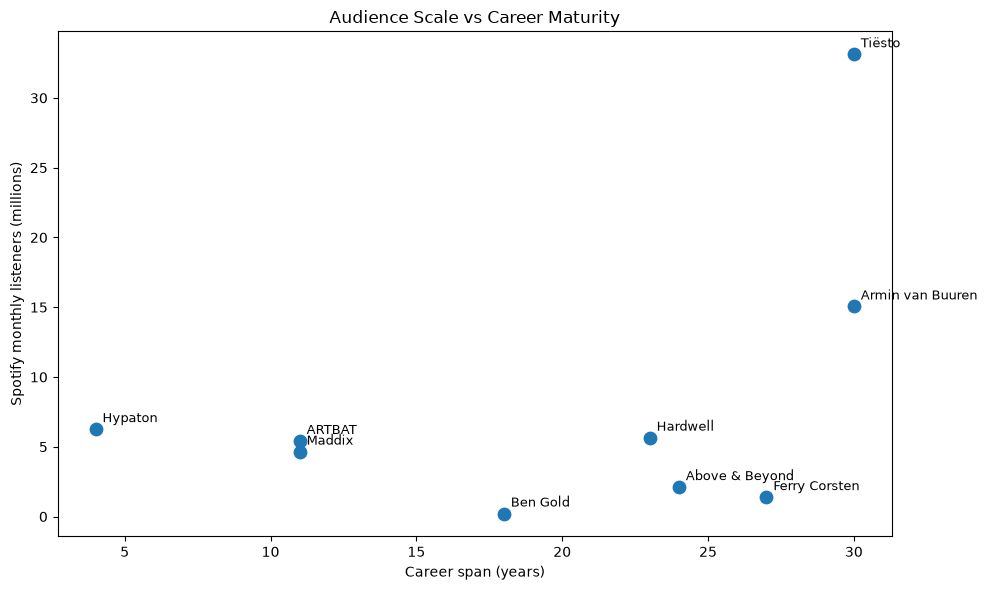

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    investigation_view["career_span_years"],
    investigation_view["spotify_monthly_listeners"] / 1_000_000,
    s=80,
)

for _, row in investigation_view.iterrows():
    ax.annotate(
        row["artist_name"],
        (
            row["career_span_years"],
            row["spotify_monthly_listeners"] / 1_000_000,
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_xlabel("Career span (years)")
ax.set_ylabel("Spotify monthly listeners (millions)")
ax.set_title("Audience Scale vs Career Maturity")

plt.tight_layout()
plt.show()

## Current Release Activity vs Historical Behaviour

Compare 2026 YTD release activity with each artist's own historical
YTD baseline.

Positive deviation indicates activity above the artist's historical
baseline; negative deviation indicates activity below it.

Release activity is treated as contextual evidence, not as a direct
measure of audience momentum.

In [23]:
release_context = investigation_view[
    investigation_view["historical_baseline_available"]
].copy()

release_context = release_context.sort_values(
    "release_deviation_pct",
    ascending=False
)

release_context[
    [
        "artist_name",
        "context_role",
        "releases_2026_ytd",
        "historical_ytd_avg",
        "release_deviation_pct",
        "core_releases_2026_ytd",
        "historical_core_ytd_avg",
        "core_deviation_pct",
    ]
]

,artist_name,context_role,releases_2026_ytd,historical_ytd_avg,release_deviation_pct,core_releases_2026_ytd,historical_core_ytd_avg,core_deviation_pct
5,Ferry Corsten,legacy_context,6.0,2.0,200.0,5.0,1.8,177.8
6,Hardwell,crossover_context,16.0,7.6,110.5,10.0,7.0,42.9
3,Maddix,close_context,8.0,5.4,48.1,8.0,5.0,60.0
4,Hypaton,growth_context,3.0,2.3,30.4,3.0,2.3,30.4
0,Armin van Buuren,anchor,28.0,22.2,26.1,18.0,16.4,9.8
1,Above & Beyond,close_context,11.0,8.8,25.0,4.0,4.8,-16.7
8,ARTBAT,adjacent_context,4.0,4.6,-13.0,3.0,4.2,-28.6
7,Tiësto,crossover_context,3.0,9.0,-66.7,3.0,5.4,-44.4


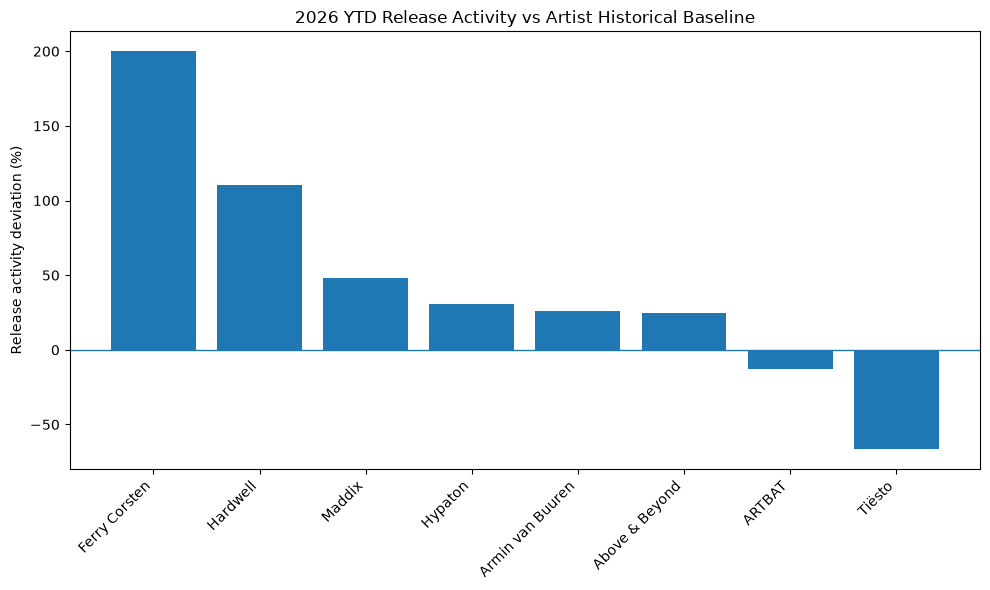

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    release_context["artist_name"],
    release_context["release_deviation_pct"],
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_ylabel("Release activity deviation (%)")
ax.set_title("2026 YTD Release Activity vs Artist Historical Baseline")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Core vs Broader Release Activity

Compare deviation in total release activity with deviation in core
release activity.

The difference helps distinguish changes in substantive artist release
activity from changes driven more heavily by remixes, compilations,
DJ mixes, live releases or other broader catalogue activity.

This is explanatory context rather than a momentum score.

In [25]:
release_context["broad_vs_core_gap"] = (
    release_context["release_deviation_pct"]
    - release_context["core_deviation_pct"]
)

release_context[
    [
        "artist_name",
        "context_role",
        "release_deviation_pct",
        "core_deviation_pct",
        "broad_vs_core_gap",
    ]
].sort_values(
    "broad_vs_core_gap",
    ascending=False
)

,artist_name,context_role,release_deviation_pct,core_deviation_pct,broad_vs_core_gap
6,Hardwell,crossover_context,110.5,42.9,67.6
1,Above & Beyond,close_context,25.0,-16.7,41.7
5,Ferry Corsten,legacy_context,200.0,177.8,22.2
0,Armin van Buuren,anchor,26.1,9.8,16.3
8,ARTBAT,adjacent_context,-13.0,-28.6,15.6
4,Hypaton,growth_context,30.4,30.4,0.0
3,Maddix,close_context,48.1,60.0,-11.9
7,Tiësto,crossover_context,-66.7,-44.4,-22.3


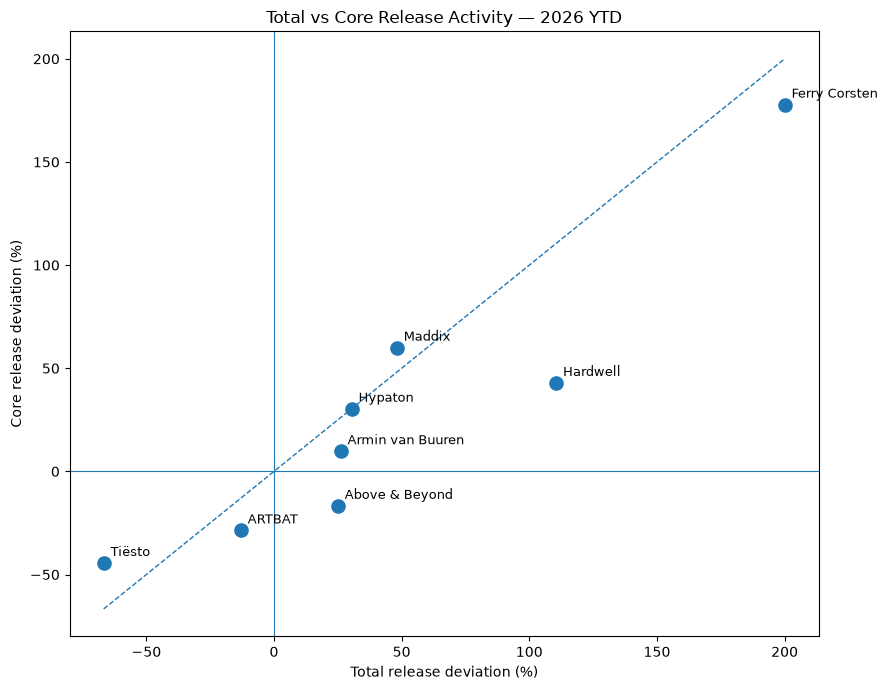

In [26]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(
    release_context["release_deviation_pct"],
    release_context["core_deviation_pct"],
    s=90,
)

for _, row in release_context.iterrows():
    ax.annotate(
        row["artist_name"],
        (
            row["release_deviation_pct"],
            row["core_deviation_pct"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

# Reference line: total deviation = core deviation
min_val = min(
    release_context["release_deviation_pct"].min(),
    release_context["core_deviation_pct"].min(),
)

max_val = max(
    release_context["release_deviation_pct"].max(),
    release_context["core_deviation_pct"].max(),
)

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1,
)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlabel("Total release deviation (%)")
ax.set_ylabel("Core release deviation (%)")
ax.set_title("Total vs Core Release Activity — 2026 YTD")

plt.tight_layout()
plt.show()

In [27]:
investigation_artists = [
    "Hypaton",
    "Maddix",
    "Hardwell",
]

artist_profiles = investigation_view[
    investigation_view["artist_name"].isin(investigation_artists)
].copy()

artist_profiles["broad_vs_core_gap"] = (
    artist_profiles["release_deviation_pct"]
    - artist_profiles["core_deviation_pct"]
)

artist_profiles[
    [
        "artist_name",
        "context_role",
        "spotify_monthly_listeners",
        "spotify_followers",
        "lastfm_listeners",
        "audience_intensity",
        "career_span_years",
        "total_releases",
        "releases_2026_ytd",
        "historical_ytd_avg",
        "release_deviation_pct",
        "core_releases_2026_ytd",
        "historical_core_ytd_avg",
        "core_deviation_pct",
        "broad_vs_core_gap",
    ]
].sort_values(
    "career_span_years"
)

,artist_name,context_role,spotify_monthly_listeners,spotify_followers,lastfm_listeners,audience_intensity,career_span_years,total_releases,releases_2026_ytd,historical_ytd_avg,release_deviation_pct,core_releases_2026_ytd,historical_core_ytd_avg,core_deviation_pct,broad_vs_core_gap
4,Hypaton,growth_context,6267536,120518,201348,6.14,4,14,3.0,2.3,30.4,3.0,2.3,30.4,0.0
3,Maddix,close_context,4651776,254996,251672,11.58,11,99,8.0,5.4,48.1,8.0,5.0,60.0,-11.9
6,Hardwell,crossover_context,5653979,3646121,777077,21.99,23,252,16.0,7.6,110.5,10.0,7.0,42.9,67.6


In [28]:
artist_profiles["spotify_listener_per_career_year"] = (
    artist_profiles["spotify_monthly_listeners"]
    / artist_profiles["career_span_years"]
)

artist_profiles[
    [
        "artist_name",
        "career_span_years",
        "spotify_monthly_listeners",
        "spotify_listener_per_career_year",
        "audience_intensity",
        "release_deviation_pct",
        "core_deviation_pct",
        "broad_vs_core_gap",
    ]
].sort_values(
    "spotify_listener_per_career_year",
    ascending=False
)

,artist_name,career_span_years,spotify_monthly_listeners,spotify_listener_per_career_year,audience_intensity,release_deviation_pct,core_deviation_pct,broad_vs_core_gap
4,Hypaton,4,6267536,1.566884e+06,6.14,30.4,30.4,0.0
3,Maddix,11,4651776,4.228887e+05,11.58,48.1,60.0,-11.9
6,Hardwell,23,5653979,2.458252e+05,21.99,110.5,42.9,67.6


## Initial Artist Investigation Findings

### Hypaton — growth-stage audience anomaly

**Observed signals**
- Spotify monthly listeners: 6.27M
- Career span: ~4 years
- Total catalogue: 14 releases
- 2026 YTD releases: 3 vs historical YTD average of 2.3 (+30.4%)
- Core releases: 3 vs historical YTD average of 2.3 (+30.4%)
- Last.fm Audience Intensity: 6.14

**Interpretation**

Hypaton occupies the most unusual audience/career position in the MVP cohort.
His current Spotify monthly-listener scale exceeds several artists with much
longer catalogue histories, despite having only ~4 years of catalogue history
and 14 releases in the MusicBrainz dataset.

Current release activity is also above his own historical baseline, and the
increase is entirely reflected in core releases rather than broader catalogue
activity.

However, his Last.fm Audience Intensity is the lowest in the cohort. This
creates an important contrast between large current Spotify reach and relatively
low cumulative listening intensity on Last.fm.

**Investigation question**

Is Hypaton's current Spotify scale evidence of a rapidly expanding artist
audience, or is it disproportionately driven by a small number of high-reach
tracks, collaborations or remixes?

Current public data cannot resolve this distinction.


### Maddix — core-led catalogue acceleration

**Observed signals**
- Spotify monthly listeners: 4.65M
- Career span: ~11 years
- Total catalogue: 99 releases
- 2026 YTD releases: 8 vs historical YTD average of 5.4 (+48.1%)
- Core releases: 8 vs historical core YTD average of 5.0 (+60.0%)
- Last.fm Audience Intensity: 11.58

**Interpretation**

Maddix combines meaningful current Spotify scale with release activity
materially above his own historical behaviour.

Unlike artists where broader catalogue activity inflates the total-release
signal, Maddix's core activity is increasing faster than total activity.
The current change therefore appears concentrated in the core artist catalogue.

His position provides a useful contemporary comparison to Hypaton: both have
multi-million Spotify audiences and elevated current release activity, but
Maddix has a substantially longer and deeper catalogue history.

**Investigation question**

Is increased core release activity accompanying sustained audience expansion,
or does it primarily reflect a temporary period of higher release cadence?

Historical audience snapshots are required to distinguish these possibilities.


### Hardwell — elevated activity with broader-catalogue effect

**Observed signals**
- Spotify monthly listeners: 5.65M
- Career span: ~23 years
- Total catalogue: 252 releases
- 2026 YTD releases: 16 vs historical YTD average of 7.6 (+110.5%)
- Core releases: 10 vs historical core YTD average of 7.0 (+42.9%)
- Last.fm Audience Intensity: 21.99

**Interpretation**

Hardwell's total 2026 release activity is substantially above his historical
baseline, but the increase is considerably smaller when restricted to core
releases.

The 67.6 percentage-point difference between total and core deviation indicates
that broader catalogue activity contributes materially to the headline increase.

This demonstrates why raw release counts should not be interpreted as momentum
without understanding catalogue composition.

**Investigation question**

What types of non-core releases account for the unusually high total activity,
and do they represent a meaningful change in catalogue strategy?

## Audience Scale vs Audience Intensity

Spotify monthly listeners provide a current audience-scale snapshot.

Last.fm Audience Intensity is defined as cumulative Last.fm playcount divided
by cumulative Last.fm listeners. It describes listening depth within the
Last.fm dataset rather than current audience growth.

Comparing the two may reveal artists with similar current audience scale but
different historical listening profiles.

Neither metric should be interpreted independently as artist momentum.

In [29]:
audience_context = investigation_view[
    [
        "artist_name",
        "context_role",
        "spotify_monthly_listeners",
        "lastfm_listeners",
        "audience_intensity",
        "career_span_years",
        "total_releases",
    ]
].copy()

audience_context["spotify_monthly_listeners_m"] = (
    audience_context["spotify_monthly_listeners"] / 1_000_000
)

audience_context = audience_context.sort_values(
    "spotify_monthly_listeners",
    ascending=False
)

audience_context

,artist_name,context_role,spotify_monthly_listeners,lastfm_listeners,audience_intensity,career_span_years,total_releases,spotify_monthly_listeners_m
7,Tiësto,crossover_context,33124303,2823523,25.24,30,320,33.124303
0,Armin van Buuren,anchor,15055533,1787889,34.96,30,563,15.055533
4,Hypaton,growth_context,6267536,201348,6.14,4,14,6.267536
6,Hardwell,crossover_context,5653979,777077,21.99,23,252,5.653979
8,ARTBAT,adjacent_context,5418283,180758,11.13,11,57,5.418283
3,Maddix,close_context,4651776,251672,11.58,11,99,4.651776
1,Above & Beyond,close_context,2109959,866769,30.85,24,246,2.109959
5,Ferry Corsten,legacy_context,1392550,721033,14.84,27,162,1.392550
2,Ben Gold,close_context,215644,92324,13.51,18,50,0.215644


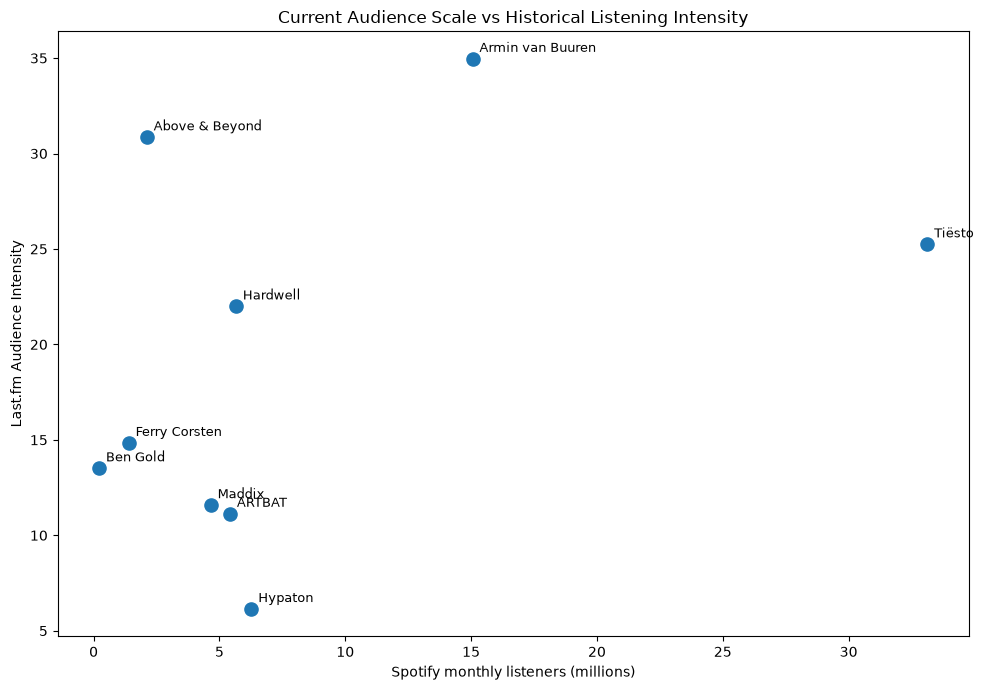

In [31]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    audience_context["spotify_monthly_listeners_m"],
    audience_context["audience_intensity"],
    s=90,
)

for _, row in audience_context.iterrows():
    ax.annotate(
        row["artist_name"],
        (
            row["spotify_monthly_listeners_m"],
            row["audience_intensity"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_xlabel("Spotify monthly listeners (millions)")
ax.set_ylabel("Last.fm Audience Intensity")
ax.set_title("Current Audience Scale vs Historical Listening Intensity")

plt.tight_layout()
plt.show()

In [32]:
audience_context[
    [
        "audience_intensity",
        "career_span_years",
        "total_releases",
        "spotify_monthly_listeners",
    ]
].corr().round(2)

,audience_intensity,career_span_years,total_releases,spotify_monthly_listeners
audience_intensity,1.00,0.82,0.92,0.41
career_span_years,0.82,1.00,0.80,0.45
total_releases,0.92,0.80,1.00,0.54
spotify_monthly_listeners,0.41,0.45,0.54,1.00


### Metric assessment — Audience Intensity

**Decision: retain as contextual evidence, not as a headline momentum signal.**

Audience Intensity (Last.fm cumulative playcount / cumulative listeners)
provides a different perspective from current Spotify audience scale.

Within the MVP cohort, however, Audience Intensity appears strongly associated
with career and catalogue maturity. Artists with longer histories have had more
time for repeated listening to accumulate on Last.fm.

Therefore:

- do not interpret higher Audience Intensity as stronger momentum;
- do not interpret it directly as fan loyalty or engagement;
- do not compare artists without career/catalogue context;
- use it to contextualize differences between current audience scale and
  accumulated historical listening behaviour.

The contrast can still surface useful investigation questions. For example,
Hypaton combines substantial current Spotify reach with low cumulative Last.fm
intensity, while established artists such as Armin van Buuren and Above &
Beyond show much higher accumulated intensity.

Determining whether these differences reflect audience growth, track-level
breakouts, collaborations, platform demographics or deeper fan relationships
requires evidence not available in the current dataset.

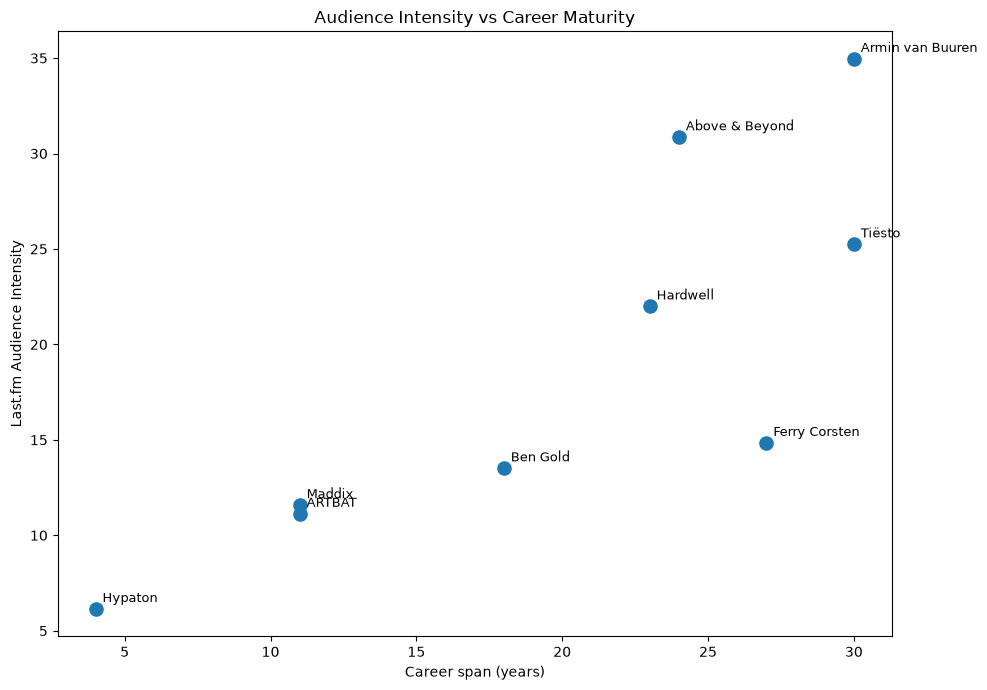

In [33]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    audience_context["career_span_years"],
    audience_context["audience_intensity"],
    s=90,
)

for _, row in audience_context.iterrows():
    ax.annotate(
        row["artist_name"],
        (
            row["career_span_years"],
            row["audience_intensity"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_xlabel("Career span (years)")
ax.set_ylabel("Last.fm Audience Intensity")
ax.set_title("Audience Intensity vs Career Maturity")

plt.tight_layout()
plt.show()

In [ ]:
## 6. Context-Relative Comparison

The MVP cohort is intentionally heterogeneous and should not be treated as
a single peer group.

This section tests whether artist interpretation changes when an artist is
viewed against the full cohort versus a more relevant contextual subset.

The purpose is not to rank artists or generate a composite score. It is to
determine whether contextual benchmarking produces more meaningful research
questions than broad cohort comparison.

In [34]:
close_context = [
    "Armin van Buuren",
    "Ferry Corsten",
    "Above & Beyond",
    "Ben Gold",
    "Maddix",
]

broad_context = artist_context["artist_name"].tolist()

growth_context = [
    "Hypaton",
    "Maddix",
    "ARTBAT",
]

In [35]:
comparison_fields = [
    "artist_name",
    "spotify_monthly_listeners",
    "career_span_years",
    "total_releases",
    "releases_2026_ytd",
    "historical_ytd_avg",
    "release_deviation_pct",
    "core_releases_2026_ytd",
    "historical_core_ytd_avg",
    "core_deviation_pct",
    "audience_intensity",
]

close_comparison = (
    investigation_view[
        investigation_view["artist_name"].isin(close_context)
    ][comparison_fields]
    .sort_values(
        "spotify_monthly_listeners",
        ascending=False,
    )
)

close_comparison

,artist_name,spotify_monthly_listeners,career_span_years,total_releases,releases_2026_ytd,historical_ytd_avg,release_deviation_pct,core_releases_2026_ytd,historical_core_ytd_avg,core_deviation_pct,audience_intensity
0,Armin van Buuren,15055533,30,563,28.0,22.2,26.1,18.0,16.4,9.8,34.96
3,Maddix,4651776,11,99,8.0,5.4,48.1,8.0,5.0,60.0,11.58
1,Above & Beyond,2109959,24,246,11.0,8.8,25.0,4.0,4.8,-16.7,30.85
5,Ferry Corsten,1392550,27,162,6.0,2.0,200.0,5.0,1.8,177.8,14.84
2,Ben Gold,215644,18,50,NaN,NaN,NaN,NaN,NaN,NaN,13.51


In [ ]:
## 7. Research Findings

The following findings synthesize the exploratory analysis across the
nine-artist MVP cohort.

They are intended as evidence-backed research observations rather than
artist rankings, momentum scores, commercial forecasts or A&R recommendations.

Each finding separates:
- observation,
- supporting evidence,
- interpretation,
- and analytical limitations or follow-up questions.

### Finding 1 — Current release activity differs materially from historical behaviour

**Observation**

Several artists are currently releasing at levels meaningfully different
from their own recent historical patterns.

**Evidence**

Among artists with sufficient historical baseline data:

- Ferry Corsten: +200.0% total release activity
- Hardwell: +110.5%
- Maddix: +48.1%
- Hypaton: +30.4%
- Armin van Buuren: +26.1%
- Above & Beyond: +25.0%
- ARTBAT: -13.0%
- Tiësto: -66.7%

These percentages compare 2026 YTD release activity with each artist's
historical activity over the equivalent portion of the year.

**Interpretation**

Absolute release counts alone do not describe current artist behaviour well.
An artist-relative historical baseline reveals whether current activity is
unusual for that particular artist.

For example, Armin van Buuren's 28 releases represent elevated activity
relative to his own historical pattern, while the significance of Ferry
Corsten's smaller absolute count becomes visible only after comparison with
his much lower historical baseline.

**Limitation / research question**

Percentage changes can become large when historical baselines are small.
Underlying release counts should therefore always accompany percentage
deviations. Release activity also measures catalogue behaviour rather than
audience or commercial momentum.

### Finding 2 — Total and core release activity can tell different stories

**Observation**

Changes in total release activity do not necessarily correspond to changes
in core release activity.

**Evidence**

Selected examples:

- Armin van Buuren: +26.1% total / +9.8% core
- Maddix: +48.1% total / +60.0% core
- Hardwell: +110.5% total / +42.9% core
- Above & Beyond: +25.0% total / -16.7% core
- ARTBAT: -13.0% total / -28.6% core
- Tiësto: -66.7% total / -44.4% core

**Interpretation**

Aggregate release volume can conceal differences in the composition of
catalogue activity.

Above & Beyond illustrates this particularly clearly: total activity is
above historical levels while core activity is below its historical
baseline. Maddix shows the opposite shape, with core activity increasing
more strongly than overall activity.

Separating core from broader catalogue activity therefore adds information
that total release counts alone would miss.

**Limitation / research question**

The result depends on the release-type classification derived from
MusicBrainz. It describes release structure, not the commercial importance,
quality or performance of individual releases.

In [ ]:
### Finding 3 — Audience scale and catalogue maturity are different dimensions

**Observation**

Artists with similar current Spotify audience scale can have substantially
different career and catalogue profiles.

**Evidence**

Examples within the cohort include:

- Hypaton: ~6.3M Spotify monthly listeners, 4-year career, 14 releases
- Hardwell: ~5.7M listeners, 23-year career, 252 releases
- ARTBAT: ~5.4M listeners, 11-year career, 57 releases
- Maddix: ~4.7M listeners, 11-year career, 99 releases

At the upper end, Tiësto and Armin van Buuren both have approximately
30-year career spans, but their current Spotify monthly audiences and
catalogue structures differ substantially.

**Interpretation**

Current audience scale should not be treated as a proxy for career maturity
or catalogue depth.

The cohort contains artists occupying similar current audience ranges while
arriving there through very different career and catalogue trajectories.
This supports analysing audience scale, career maturity and catalogue
behaviour as separate dimensions.

**Limitation / research question**

Spotify monthly listeners are a point-in-time audience measure and may be
affected by recent releases, collaborations, playlists and other factors
not represented in the current MVP dataset.

In [ ]:
### Finding 4 — Last.fm Audience Intensity is informative, but structurally confounded

**Observation**

Last.fm playcount per listener varies substantially across the cohort, but
the metric is strongly associated with catalogue and career maturity.

**Evidence**

Within this nine-artist cohort, the exploratory correlations were:

- Audience Intensity vs total releases: 0.92
- Audience Intensity vs career span: 0.82
- Audience Intensity vs Spotify monthly listeners: 0.41

Examples include:

- Armin van Buuren: 34.96
- Above & Beyond: 30.85
- Tiësto: 25.24
- Hardwell: 21.99
- Hypaton: 6.14

**Interpretation**

Playcount per listener appears to capture something different from current
audience scale, but it cannot currently be interpreted as a clean measure
of audience engagement or momentum.

Long-career artists with large catalogues have had substantially more time
and material through which to accumulate Last.fm plays.

Audience Intensity should therefore remain a contextual descriptor rather
than a momentum KPI.

**Limitation / research question**

The cohort contains only nine deliberately heterogeneous artists, so the
correlations are exploratory rather than generalizable. A larger dataset
and/or time-normalized listening measures would be required before treating
the metric as an independent audience signal.

In [ ]:
### Finding 5 — Context changes the meaning of comparison

**Observation**

The nine artists provide useful analytical variation, but they do not form
a single homogeneous peer group.

**Evidence**

The cohort deliberately spans:

- anchor context,
- close artist context,
- legacy context,
- crossover context,
- adjacent contemporary context,
- and growth context.

Within the closer contextual comparison, Armin van Buuren combines:

- ~15.1M Spotify monthly listeners,
- a 30-year career,
- 563 catalogue releases,
- +26.1% total release deviation,
- and +9.8% core release deviation.

Other contextual artists show different activity structures. For example,
Maddix is +48.1% total / +60.0% core, while Above & Beyond is +25.0% total /
-16.7% core.

**Interpretation**

Peer-relative signals should not be interpreted independently of artist
context.

Comparing an established artist, a growth-stage artist and a crossover
artist can reveal useful contrasts, but treating them as interchangeable
peers would obscure differences in career stage, catalogue structure and
audience scale.

The heterogeneous cohort is therefore most useful as a contextual research
set rather than as a ranking universe.

**Limitation / research question**

Context roles are research constructs rather than objective artist
categories. A business review should determine which comparison sets are
most meaningful for specific A&R, catalogue or marketing questions.

In [ ]:
## 8. Business Stream Handover

### Purpose

The technical stream has completed the first contextual analysis of the
nine-artist Artist Momentum & Context MVP.

The objective was not to rank artists or produce an A&R recommendation.
It was to test whether public catalogue and audience data can generate
interpretable signals that are useful for artist research.

---

### A. Established Evidence

#### 1. Artist-relative release behaviour reveals information hidden by absolute counts

2026 YTD release activity differs materially from artists' own historical
patterns.

Examples include:

- Ferry Corsten: +200.0%
- Hardwell: +110.5%
- Maddix: +48.1%
- Hypaton: +30.4%
- Armin van Buuren: +26.1%
- Above & Beyond: +25.0%
- ARTBAT: -13.0%
- Tiësto: -66.7%

These signals should be interpreted together with the underlying counts,
particularly where historical baselines are small.

#### 2. Core and broader catalogue activity can move differently

Total release activity alone can conceal changes in catalogue composition.

Examples:

- Armin van Buuren: +26.1% total / +9.8% core
- Maddix: +48.1% total / +60.0% core
- Hardwell: +110.5% total / +42.9% core
- Above & Beyond: +25.0% total / -16.7% core

This suggests that separating core from broader catalogue activity adds
analytical information beyond release volume alone.

#### 3. Similar current audience scale can represent very different artist trajectories

Hypaton, Hardwell, ARTBAT and Maddix currently occupy broadly comparable
Spotify monthly-listener ranges in this cohort, while differing substantially
in career length and catalogue size.

Current audience scale therefore should not be treated as a proxy for
career maturity or catalogue depth.

#### 4. Last.fm Audience Intensity should be treated cautiously

Playcount per listener is strongly associated in this small cohort with:

- total releases: r = 0.92
- career span: r = 0.82

Its relationship with current Spotify monthly listeners is weaker:

- Spotify monthly listeners: r = 0.41

The metric may contain useful contextual information, but it should not
currently be treated as an independent engagement or momentum KPI.

#### 5. Artist context materially affects interpretation

The nine-artist cohort is intentionally heterogeneous.

It is useful for exposing different artist patterns, but should not be
treated as a single ranking universe. Relevant comparison sets depend on
career stage, catalogue structure, audience scale and the business question
being investigated.

---

### B. Methodological Findings

The MVP analysis currently supports the following working principles:

1. Compare an artist with their own historical behaviour before comparing
   them with other artists.

2. Separate current audience scale from career and catalogue maturity.

3. Separate core release activity from broader catalogue activity.

4. Show underlying counts alongside percentage deviations.

5. Treat cross-platform metrics as complementary signals rather than
   interchangeable measures.

6. Treat correlations from the nine-artist cohort as exploratory evidence,
   not generalizable relationships.

7. Use artist cohorts as contextual research sets rather than automatically
   converting them into rankings or composite scores.

8. Treat signals as starting points for investigation rather than
   recommendations.

---

### C. Questions for Business Review

The technical stream now needs Research & Insights / A&R judgment on the
following questions:

**Business relevance**

Which of these signals would actually help an A&R, catalogue or marketing
team investigate an artist?

**Context selection**

Which artists constitute meaningful comparison sets for different research
questions? Should close peers, career-stage comparators and adjacent-scene
artists be analysed differently?

**Release activity**

When would unusually high or low release activity warrant deeper
investigation? What additional context would be required before it becomes
commercially meaningful?

**Catalogue composition**

Is the distinction between core and broader release activity useful from a
label perspective, and should the current MusicBrainz-derived definition be
refined?

**Audience context**

Which additional audience signals would materially improve interpretation
without creating a large data-acquisition exercise?

**Decision boundary**

At what point does a public-data signal become strong enough to trigger
further research, while still avoiding an automated signing or marketing
recommendation?

---

### Technical Stream Recommendation

Do not add another external data source yet.

The current MVP already produces interpretable differences across audience
scale, career maturity, catalogue structure and release behaviour.

The next step should be business validation of these findings. Additional
data should only be introduced where the business review identifies a
specific unanswered question that the current evidence cannot address.

## 9. Core Release Classification Validation

Before using core vs broader catalogue activity in the final case studies,
the MusicBrainz-derived classification is manually validated against a
sample of releases.

The purpose is not to establish a perfect catalogue taxonomy. It is to
determine whether the current transformation produces sufficiently
interpretable distinctions for the MVP.

Artists reviewed:
- Armin van Buuren
- Maddix
- Above & Beyond

In [36]:
validation_base = con.execute("""
    SELECT
        artist_name,
        title,
        primary_type,
        first_release_date,
        is_compilation,
        is_remix,
        is_live,
        is_dj_mix
    FROM release_catalogue
    WHERE artist_name IN (
        'Armin van Buuren',
        'Maddix',
        'Above & Beyond'
    )
    ORDER BY artist_name, first_release_date DESC
""").fetchdf()

validation_base.head(20)

,artist_name,title,primary_type,first_release_date,is_compilation,is_remix,is_live,is_dj_mix
0,Above & Beyond,Sun & Moon (downtempo version),Single,2026-09-14,False,True,False,False
1,Above & Beyond,Quicksand (Don’t Go) (The Remixes),EP,2026-09-03,False,True,False,False
2,Above & Beyond,Quicksand (Don’t Go) (Ben Nicky remix),Single,2026-08-27,False,True,False,False
3,Above & Beyond,When You Believe,Single,2026-08-14,False,False,False,False
4,Above & Beyond,One Mix with Above & Beyond,Album,2026-07-24,False,False,False,True
5,Above & Beyond,Homecoming (Tim Green remix),Single,2026-07-06,False,True,False,False
6,Above & Beyond,Major Drop,Single,2026-06-24,False,False,False,False
7,Above & Beyond,Feel the Vibe,Single,2026-06-05,False,False,False,False
8,Above & Beyond,Anjunabeats Volume 17,Album,2026-06-05,True,False,False,True
9,Above & Beyond,When I Look in Your Eyes,Single,2026-05-06,False,False,False,False


In [37]:
validation_base["model_classification"] = (
    ~validation_base["is_remix"]
    & ~validation_base["is_compilation"]
    & ~validation_base["is_live"]
    & ~validation_base["is_dj_mix"]
).map({
    True: "Core",
    False: "Broader"
})

validation_base[
    [
        "artist_name",
        "title",
        "primary_type",
        "first_release_date",
        "model_classification",
        "is_remix",
        "is_compilation",
        "is_live",
        "is_dj_mix",
    ]
].head(30)

,artist_name,title,primary_type,first_release_date,model_classification,is_remix,is_compilation,is_live,is_dj_mix
0,Above & Beyond,Sun & Moon (downtempo version),Single,2026-09-14,Broader,True,False,False,False
1,Above & Beyond,Quicksand (Don’t Go) (The Remixes),EP,2026-09-03,Broader,True,False,False,False
2,Above & Beyond,Quicksand (Don’t Go) (Ben Nicky remix),Single,2026-08-27,Broader,True,False,False,False
3,Above & Beyond,When You Believe,Single,2026-08-14,Core,False,False,False,False
4,Above & Beyond,One Mix with Above & Beyond,Album,2026-07-24,Broader,False,False,False,True
5,Above & Beyond,Homecoming (Tim Green remix),Single,2026-07-06,Broader,True,False,False,False
6,Above & Beyond,Major Drop,Single,2026-06-24,Core,False,False,False,False
7,Above & Beyond,Feel the Vibe,Single,2026-06-05,Core,False,False,False,False
8,Above & Beyond,Anjunabeats Volume 17,Album,2026-06-05,Broader,False,True,False,True
9,Above & Beyond,When I Look in Your Eyes,Single,2026-05-06,Core,False,False,False,False


In [38]:
validation_sample = (
    validation_base[
        validation_base["artist_name"].isin(
            ["Armin van Buuren", "Maddix", "Above & Beyond"]
        )
    ]
    .sort_values(
        ["artist_name", "first_release_date"],
        ascending=[True, False]
    )
    .groupby("artist_name")
    .head(20)
)

validation_sample[
    [
        "artist_name",
        "title",
        "primary_type",
        "first_release_date",
        "model_classification",
        "is_remix",
        "is_compilation",
        "is_live",
        "is_dj_mix",
    ]
]

,artist_name,title,primary_type,first_release_date,model_classification,is_remix,is_compilation,is_live,is_dj_mix
0,Above & Beyond,Sun & Moon (downtempo version),Single,2026-09-14,Broader,True,False,False,False
1,Above & Beyond,Quicksand (Don’t Go) (The Remixes),EP,2026-09-03,Broader,True,False,False,False
2,Above & Beyond,Quicksand (Don’t Go) (Ben Nicky remix),Single,2026-08-27,Broader,True,False,False,False
3,Above & Beyond,When You Believe,Single,2026-08-14,Core,False,False,False,False
4,Above & Beyond,One Mix with Above & Beyond,Album,2026-07-24,Broader,False,False,False,True
5,Above & Beyond,Homecoming (Tim Green remix),Single,2026-07-06,Broader,True,False,False,False
6,Above & Beyond,Major Drop,Single,2026-06-24,Core,False,False,False,False
7,Above & Beyond,Feel the Vibe,Single,2026-06-05,Core,False,False,False,False
8,Above & Beyond,Anjunabeats Volume 17,Album,2026-06-05,Broader,False,True,False,True
9,Above & Beyond,When I Look in Your Eyes,Single,2026-05-06,Core,False,False,False,False


## Case Study 1 — Maddix

### Question
How unusual is Maddix's recent release activity relative to his own history,
and is the change concentrated in core artist releases?

In [39]:
maddix_history = con.execute("""
    SELECT
        release_year,
        total_releases,
        core_releases,
        singles,
        albums,
        eps,
        remixes,
        compilations,
        dj_mixes,
        live_releases
    FROM gold_release_metrics
    WHERE artist_name = 'Maddix'
    ORDER BY release_year
""").fetchdf()

maddix_history

,release_year,total_releases,core_releases,singles,albums,eps,remixes,compilations,dj_mixes,live_releases
0,2015,3,3,3,0,0,0,0,0,0
1,2016,5,4,4,1,0,0,1,0,0
2,2017,7,7,7,0,0,0,0,0,0
3,2018,9,7,8,1,0,1,0,1,0
4,2019,10,6,10,0,0,4,0,0,0
5,2020,9,9,8,0,1,0,0,0,0
6,2021,11,9,10,1,0,1,1,0,0
7,2022,7,7,7,0,0,0,0,0,0
8,2023,8,7,8,0,0,1,0,0,0
9,2024,12,9,11,1,0,1,1,0,1


In [40]:
maddix_recent = con.execute("""
    SELECT
        first_release_date,
        title,
        primary_type,
        is_remix,
        is_compilation,
        is_live,
        is_dj_mix,
        CASE
            WHEN is_remix = FALSE
             AND is_compilation = FALSE
             AND is_live = FALSE
             AND is_dj_mix = FALSE
            THEN 'Core'
            ELSE 'Broader'
        END AS release_class
    FROM release_catalogue
    WHERE artist_name = 'Maddix'
      AND YEAR(first_release_date) >= 2024
    ORDER BY first_release_date
""").fetchdf()

maddix_recent

,first_release_date,title,primary_type,is_remix,is_compilation,is_live,is_dj_mix,release_class
0,2024-01-12,Spiritum,Single,False,False,False,False,Core
1,2024-02-02,Open Sesame (Abracadabra),Single,False,False,False,False,Core
2,2024-03-29,16,Single,False,False,False,False,Core
3,2024-04-12,Adrenalina (Minha Gasolina),Single,False,False,False,False,Core
4,2024-05-03,Open Sesame (Abracadabra) (D-Block & S-te-Fan ...,Single,True,False,False,False,Broader
5,2024-05-17,Meet Her At The Love Parade,Single,False,False,False,False,Core
6,2024-06-28,Love Takes Over,Single,False,False,False,False,Core
7,2024-08-23,My Fantasy,Single,False,False,False,False,Core
8,2024-10-18,I'm From Holland,Single,False,False,False,False,Core
9,2024-11-15,Direct Dizko,Single,False,False,False,False,Core


In [41]:
maddix_core = (
    maddix_recent[
        maddix_recent["release_class"] == "Core"
    ]
    .copy()
)

maddix_core["first_release_date"] = pd.to_datetime(
    maddix_core["first_release_date"]
)

maddix_core = maddix_core.sort_values("first_release_date")

maddix_core["days_since_previous_core_release"] = (
    maddix_core["first_release_date"].diff().dt.days
)

maddix_core["release_year"] = (
    maddix_core["first_release_date"].dt.year
)

maddix_core[
    [
        "first_release_date",
        "title",
        "primary_type",
        "days_since_previous_core_release",
    ]
]

,first_release_date,title,primary_type,days_since_previous_core_release
0,2024-01-12,Spiritum,Single,NaN
1,2024-02-02,Open Sesame (Abracadabra),Single,21.0
2,2024-03-29,16,Single,56.0
3,2024-04-12,Adrenalina (Minha Gasolina),Single,14.0
5,2024-05-17,Meet Her At The Love Parade,Single,35.0
6,2024-06-28,Love Takes Over,Single,42.0
7,2024-08-23,My Fantasy,Single,56.0
8,2024-10-18,I'm From Holland,Single,56.0
9,2024-11-15,Direct Dizko,Single,28.0
12,2025-02-28,Hellfire,Single,105.0


In [42]:
maddix_cadence = (
    maddix_core
    .groupby("release_year")
    .agg(
        core_releases=("title", "count"),
        median_days_between_releases=(
            "days_since_previous_core_release", "median"
        ),
        mean_days_between_releases=(
            "days_since_previous_core_release", "mean"
        ),
    )
    .round(1)
)

maddix_cadence

,core_releases,median_days_between_releases,mean_days_between_releases
release_year,,,
2024,9,38.5,38.5
2025,9,35.0,43.6
2026,8,28.0,28.0


In [43]:
maddix_audience_history = con.execute("""
    SELECT
        artist_name,
        snapshot_date,
        listeners,
        playcount,
        playcount_per_listener
    FROM gold_lastfm_audience_metrics
    WHERE artist_name = 'Maddix'
    ORDER BY snapshot_date
""").fetchdf()

maddix_audience_history

,artist_name,snapshot_date,listeners,playcount,playcount_per_listener
0,Maddix,2026-09-30,251672,2914685,11.58


In [44]:
spotify_maddix = pd.read_csv(
    "../data/manual/spotify_artist_snapshot.csv"
)

spotify_maddix[
    spotify_maddix["artist_name"] == "Maddix"
]

,artist_name,snapshot_date,spotify_monthly_listeners,spotify_followers,source
5,Maddix,2026-09-30,4651776,254996,Spotify manual snapshot


In [45]:
con.close()

In [46]:
import duckdb

con = duckdb.connect("../music_artist_insights.duckdb")

In [50]:
snapshot_check = con.execute("""
    SELECT
        artist_name,
        snapshot_date,
        listeners,
        playcount,
        playcount_per_listener
    FROM gold_lastfm_audience_metrics
    WHERE artist_name IN (
        'Maddix',
        'Hardwell',
        'Above & Beyond',
        'Hypaton'
    )
    ORDER BY artist_name, snapshot_date
""").fetchdf()

snapshot_check

,artist_name,snapshot_date,listeners,playcount,playcount_per_listener
0,Above & Beyond,2026-09-30,866769,26743979,30.85
1,Above & Beyond,2026-10-03,866862,26747761,30.86
2,Hardwell,2026-09-30,777077,17085445,21.99
3,Hardwell,2026-10-03,777180,17086916,21.99
4,Hypaton,2026-09-30,201348,1237204,6.14
5,Hypaton,2026-10-03,201400,1237601,6.14
6,Maddix,2026-09-30,251672,2914685,11.58
7,Maddix,2026-10-03,251787,2915808,11.58


In [51]:
con.close()

In [52]:
con = duckdb.connect("../music_artist_insights.duckdb")

In [53]:
maddix_snapshots = snapshot_check[
    snapshot_check["artist_name"] == "Maddix"
].sort_values("snapshot_date").copy()

maddix_snapshots["listener_change"] = (
    maddix_snapshots["listeners"].diff()
)

maddix_snapshots["listener_change_pct"] = (
    maddix_snapshots["listeners"].pct_change() * 100
)

maddix_snapshots["playcount_change"] = (
    maddix_snapshots["playcount"].diff()
)

maddix_snapshots[
    [
        "snapshot_date",
        "listeners",
        "listener_change",
        "listener_change_pct",
        "playcount",
        "playcount_change",
        "playcount_per_listener"
    ]
].round(3)

/var/folders/n3/m2px247567bd0zrky2q6tmlw0000gn/T/ipykernel_19699/4276336896.py:27: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(3)


,snapshot_date,listeners,listener_change,listener_change_pct,playcount,playcount_change,playcount_per_listener
6,2026-09-30,251672,NaN,NaN,2914685,NaN,11.58
7,2026-10-03,251787,115.0,0.046,2915808,1123.0,11.58


# Case Study 2 — Hardwell

## Question
What is driving Hardwell's unusually high 2026 release activity, and does the available audience evidence show corresponding demand acceleration?

In [54]:
hardwell_release_history = con.execute("""
    SELECT
        release_year,
        total_releases,
        core_releases,
        singles,
        albums,
        eps,
        remixes,
        compilations,
        dj_mixes,
        live_releases
    FROM gold_release_metrics
    WHERE artist_name = 'Hardwell'
    ORDER BY release_year
""").fetchdf()

hardwell_release_history

,release_year,total_releases,core_releases,singles,albums,eps,remixes,compilations,dj_mixes,live_releases
0,2003,1,0,0,1,0,0,1,1,0
1,2006,2,0,0,2,0,1,2,1,0
2,2007,3,0,0,3,0,2,3,3,0
3,2008,4,2,2,2,0,1,2,1,0
4,2009,8,5,5,3,0,0,3,3,0
5,2010,7,5,4,2,1,1,1,2,0
6,2011,7,6,6,1,0,0,1,1,0
7,2012,11,7,9,1,1,3,1,1,0
8,2013,10,7,8,2,0,2,0,1,0
9,2014,14,7,12,1,1,6,1,1,0


In [55]:
hardwell_recent_releases = con.execute("""
    SELECT
        first_release_date,
        title,
        primary_type,
        is_remix,
        is_compilation,
        is_live,
        is_dj_mix,
        CASE
            WHEN is_remix = FALSE
             AND is_compilation = FALSE
             AND is_live = FALSE
             AND is_dj_mix = FALSE
            THEN 'Core'
            ELSE 'Broader'
        END AS release_class
    FROM release_catalogue
    WHERE artist_name = 'Hardwell'
      AND YEAR(first_release_date) >= 2024
    ORDER BY first_release_date
""").fetchdf()

hardwell_recent_releases

,first_release_date,title,primary_type,is_remix,is_compilation,is_live,is_dj_mix,release_class
0,2024-01-05,Oldskool Sound,Single,False,False,False,False,Core
1,2024-02-09,Energy,Single,False,False,False,False,Core
2,2024-03-29,16,Single,False,False,False,False,Core
3,2024-06-07,Move,Single,False,False,False,False,Core
4,2024-07-12,XTC,Single,False,False,False,False,Core
5,2024-08-16,I’m the Devil,Single,False,False,False,False,Core
6,2024-09-06,Follow the Light,Single,False,False,False,False,Core
7,2024-10-11,Falling in Love,Single,False,False,False,False,Core
8,2024-11-08,No Sleep,Single,False,False,False,False,Core
9,2024-12-13,Cambodia,Single,False,False,False,False,Core


In [56]:
hardwell_core = hardwell_recent_releases[
    hardwell_recent_releases["release_class"] == "Core"
].copy()

hardwell_core["first_release_date"] = pd.to_datetime(
    hardwell_core["first_release_date"]
)

hardwell_core = hardwell_core.sort_values("first_release_date")

hardwell_core["days_since_previous_core_release"] = (
    hardwell_core["first_release_date"].diff().dt.days
)

hardwell_core["release_year"] = (
    hardwell_core["first_release_date"].dt.year
)

hardwell_cadence = (
    hardwell_core
    .groupby("release_year")
    .agg(
        core_releases=("title", "count"),
        median_days_between_releases=(
            "days_since_previous_core_release", "median"
        ),
        mean_days_between_releases=(
            "days_since_previous_core_release", "mean"
        )
    )
    .round(1)
)

hardwell_cadence

,core_releases,median_days_between_releases,mean_days_between_releases
release_year,,,
2024,10,35.0,38.1
2025,10,28.0,35.7
2026,10,22.0,27.3


In [57]:
hardwell_core[
    [
        "first_release_date",
        "title",
        "primary_type",
        "days_since_previous_core_release"
    ]
]

,first_release_date,title,primary_type,days_since_previous_core_release
0,2024-01-05,Oldskool Sound,Single,NaN
1,2024-02-09,Energy,Single,35.0
2,2024-03-29,16,Single,49.0
3,2024-06-07,Move,Single,70.0
4,2024-07-12,XTC,Single,35.0
5,2024-08-16,I’m the Devil,Single,35.0
6,2024-09-06,Follow the Light,Single,21.0
7,2024-10-11,Falling in Love,Single,35.0
8,2024-11-08,No Sleep,Single,28.0
9,2024-12-13,Cambodia,Single,35.0


In [58]:
hardwell_audience_history = con.execute("""
    SELECT
        snapshot_date,
        listeners,
        listener_change,
        listener_growth_pct,
        playcount,
        playcount_change,
        playcount_growth_pct,
        playcount_per_listener
    FROM gold_lastfm_audience_metrics
    WHERE artist_name = 'Hardwell'
    ORDER BY snapshot_date
""").fetchdf()

hardwell_audience_history

,snapshot_date,listeners,listener_change,listener_growth_pct,playcount,playcount_change,playcount_growth_pct,playcount_per_listener
0,2026-09-30,777077,<NA>,NaN,17085445,<NA>,NaN,21.99
1,2026-10-03,777180,103,0.01,17086916,1471,0.01,21.99


In [59]:
# ============================================================
# CASE STUDY 3 — ABOVE & BEYOND
# ============================================================

ab_release_history = con.execute("""
    SELECT *
    FROM gold_release_metrics
    WHERE artist_name = 'Above & Beyond'
      AND release_year >= 2024
    ORDER BY release_year
""").fetchdf()

ab_release_history

,artist_name,release_year,total_releases,core_releases,singles,albums,eps,remixes,compilations,dj_mixes,live_releases,previous_year_releases,yoy_release_change,yoy_release_pct,comparable_ytd_releases,comparable_ytd_core_releases,dataset_through_date
0,Above & Beyond,2024,11,6,7,3,1,2,1,1,1,7,4,57.1,8,3,2026-09-14
1,Above & Beyond,2025,15,10,11,3,1,4,1,1,0,11,4,36.4,11,9,2026-09-14
2,Above & Beyond,2026,11,4,8,2,1,5,1,2,0,15,-4,-26.7,11,4,2026-09-14


In [60]:
ab_releases = con.execute("""
    SELECT
        first_release_date,
        title,
        primary_type,
        is_remix,
        is_compilation,
        is_live,
        is_dj_mix,
        CASE
            WHEN is_remix = FALSE
             AND is_compilation = FALSE
             AND is_live = FALSE
             AND is_dj_mix = FALSE
            THEN 'Core'
            ELSE 'Broader'
        END AS release_class
    FROM release_catalogue
    WHERE artist_name = 'Above & Beyond'
      AND YEAR(first_release_date) >= 2024
    ORDER BY first_release_date
""").fetchdf()

ab_releases

,first_release_date,title,primary_type,is_remix,is_compilation,is_live,is_dj_mix,release_class
0,2024-01-01,Group Therapy 500 (live From Los Angeles),Album,False,False,True,False,Broader
1,2024-01-18,Sirens of the Sea (Marsh remix),Single,True,False,False,False,Broader
2,2024-02-09,Crazy Love,Single,False,False,False,False,Core
3,2024-03-15,The Anthology,Album,False,True,False,False,Broader
4,2024-03-25,Crazy Love (ANUQRAM remix),Single,True,False,False,False,Broader
5,2024-05-16,The Anjunadeep Edition 500 With Above & Beyond,Album,False,False,False,True,Broader
6,2024-07-30,Palermo / Fractals,Single,False,False,False,False,Core
7,2024-09-05,Heart of Stone,Single,False,False,False,False,Core
8,2024-11-01,React,Single,False,False,False,False,Core
9,2024-11-20,Another Breakdown,Single,False,False,False,False,Core


In [61]:
ab_core = ab_releases[
    ab_releases["release_class"] == "Core"
].copy()

ab_core["release_year"] = (
    ab_core["first_release_date"].dt.year
)

ab_core["days_since_previous_core_release"] = (
    ab_core["first_release_date"].diff().dt.days
)

ab_cadence = (
    ab_core[
        ab_core["release_year"].isin([2024, 2025, 2026])
    ]
    .groupby("release_year")
    .agg(
        core_releases=("title", "count"),
        median_days_between_releases=(
            "days_since_previous_core_release", "median"
        ),
        mean_days_between_releases=(
            "days_since_previous_core_release", "mean"
        ),
    )
)

ab_cadence

,core_releases,median_days_between_releases,mean_days_between_releases
release_year,,,
2024,6,37.0,60.2
2025,10,31.5,37.0
2026,4,40.5,61.5


In [62]:
ab_core[
    [
        "first_release_date",
        "title",
        "primary_type",
        "days_since_previous_core_release",
    ]
]

,first_release_date,title,primary_type,days_since_previous_core_release
2,2024-02-09,Crazy Love,Single,NaN
6,2024-07-30,Palermo / Fractals,Single,172.0
7,2024-09-05,Heart of Stone,Single,37.0
8,2024-11-01,React,Single,57.0
9,2024-11-20,Another Breakdown,Single,19.0
10,2024-12-06,Tranquility Base Vol. 2,EP,16.0
11,2025-01-14,Shall We Begin,Single,39.0
13,2025-03-21,Quicksand (Don’t Go),Single,66.0
14,2025-04-25,Carry Me Home,Single,35.0
15,2025-05-30,Start a Fire,Single,35.0


In [63]:
ab_audience = con.execute("""
    SELECT
        snapshot_date,
        listeners,
        listener_change,
        listener_growth_pct,
        playcount,
        playcount_change,
        playcount_growth_pct,
        playcount_per_listener
    FROM gold_lastfm_audience_metrics
    WHERE artist_name = 'Above & Beyond'
    ORDER BY snapshot_date
""").fetchdf()

ab_audience

,snapshot_date,listeners,listener_change,listener_growth_pct,playcount,playcount_change,playcount_growth_pct,playcount_per_listener
0,2026-09-30,866769,<NA>,NaN,26743979,<NA>,NaN,30.85
1,2026-10-03,866862,93,0.01,26747761,3782,0.01,30.86


In [64]:
# ============================================================
# CASE STUDY 4 — HYPATON
# ============================================================

hypaton_release_history = con.execute("""
    SELECT *
    FROM gold_release_metrics
    WHERE artist_name = 'Hypaton'
    ORDER BY release_year
""").fetchdf()

hypaton_release_history

,artist_name,release_year,total_releases,core_releases,singles,albums,eps,remixes,compilations,dj_mixes,live_releases,previous_year_releases,yoy_release_change,yoy_release_pct,comparable_ytd_releases,comparable_ytd_core_releases,dataset_through_date
0,Hypaton,2022,1,1,1,0,0,0,0,0,0,<NA>,<NA>,NaN,1,1,2026-09-11
1,Hypaton,2023,2,2,2,0,0,0,0,0,0,1,1,100.0,2,2,2026-09-11
2,Hypaton,2024,2,1,2,0,0,1,0,0,0,2,0,0.0,1,1,2026-09-11
3,Hypaton,2025,6,5,5,0,1,1,0,0,0,2,4,200.0,5,5,2026-09-11
4,Hypaton,2026,3,3,3,0,0,0,0,0,0,6,-3,-50.0,3,3,2026-09-11


In [65]:
hypaton_releases = con.execute("""
    SELECT
        first_release_date,
        title,
        primary_type,
        is_remix,
        is_compilation,
        is_live,
        is_dj_mix,
        CASE
            WHEN is_remix = FALSE
             AND is_compilation = FALSE
             AND is_live = FALSE
             AND is_dj_mix = FALSE
            THEN 'Core'
            ELSE 'Broader'
        END AS release_class
    FROM release_catalogue
    WHERE artist_name = 'Hypaton'
    ORDER BY first_release_date
""").fetchdf()

hypaton_releases

,first_release_date,title,primary_type,is_remix,is_compilation,is_live,is_dj_mix,release_class
0,2022-08-12,Hello Peter (Giuseppe Ottaviani Retouch),Single,False,False,False,False,Core
1,2023-04-21,Be My Lover (2023 mix),Single,False,False,False,False,Core
2,2023-04-21,Be My Lover (2023 mix),Single,False,False,False,False,Core
3,2024-04-12,Feeling Good,Single,False,False,False,False,Core
4,2024-12-13,Akon’s Beautiful Day (David Guetta & Hypaton r...,Single,True,False,False,False,Broader
5,2025-03-07,Time Is the Healer,Single,False,False,False,False,Core
6,2025-05-09,The Final Countdown 2025,Single,False,False,False,False,Core
7,2025-07-04,Together,Single,False,False,False,False,Core
8,2025-07-18,Outta My Head,Single,False,False,False,False,Core
9,2025-07-18,Outta My Head,Single,False,False,False,False,Core


In [66]:
hypaton_duplicates = (
    hypaton_releases
    .groupby(
        ["first_release_date", "title"],
        dropna=False
    )
    .size()
    .reset_index(name="record_count")
    .query("record_count > 1")
)

hypaton_duplicates

,first_release_date,title,record_count
1,2023-04-21,Be My Lover (2023 mix),2
7,2025-07-18,Outta My Head,2


In [67]:
hypaton_duplicate_detail = con.execute("""
    SELECT *
    FROM release_catalogue
    WHERE artist_name = 'Hypaton'
      AND (
          title = 'Be My Lover (2023 mix)'
          OR title = 'Outta My Head'
      )
    ORDER BY title, first_release_date
""").fetchdf()

hypaton_duplicate_detail

,artist_name,release_group_id,title,primary_type,first_release_date,is_compilation,is_remix,is_live,is_dj_mix
0,Hypaton,26584962-63f2-4fb3-bac9-2aba61924a9c,Be My Lover (2023 mix),Single,2023-04-21,False,False,False,False
1,Hypaton,b9a372a7-98b7-4d47-9e8c-019204aaaea4,Be My Lover (2023 mix),Single,2023-04-21,False,False,False,False
2,Hypaton,0464c2da-e7cb-47f9-adc7-0357c151ecaa,Outta My Head,Single,2025-07-18,False,False,False,False
3,Hypaton,e8f2b0c9-7c0b-4207-8726-609d679678be,Outta My Head,Single,2025-07-18,False,False,False,False


In [68]:
cohort_duplicates = con.execute("""
    SELECT
        artist_name,
        first_release_date,
        title,
        primary_type,
        COUNT(*) AS record_count
    FROM release_catalogue
    GROUP BY
        artist_name,
        first_release_date,
        title,
        primary_type
    HAVING COUNT(*) > 1
    ORDER BY
        artist_name,
        first_release_date,
        title
""").fetchdf()

cohort_duplicates

,artist_name,first_release_date,title,primary_type,record_count
0,ARTBAT,2024-07-19,The Ocean,Single,2
1,Armin van Buuren,2022-08-26,Clap,Single,2
2,Armin van Buuren,2025-08-08,Sleepless Nights,Single,2
3,Ferry Corsten,2006-02-20,Whatever!,Single,2
4,Hypaton,2023-04-21,Be My Lover (2023 mix),Single,2
5,Hypaton,2025-07-18,Outta My Head,Single,2
6,Tiësto,2007-07-01,Break My Fall,Single,2
7,Tiësto,2017-04-24,BOOM,Single,2
8,Tiësto,2024-07-02,ZENLESS,Single,2


In [69]:
cohort_duplicates.groupby("artist_name").agg(
    duplicate_release_groups=("record_count", "count"),
    excess_records=("record_count", lambda x: (x - 1).sum())
).sort_values(
    "excess_records",
    ascending=False
)

,duplicate_release_groups,excess_records
artist_name,,
Tiësto,3,3
Armin van Buuren,2,2
Hypaton,2,2
ARTBAT,1,1
Ferry Corsten,1,1


In [70]:
con.close()

In [71]:
import duckdb

con = duckdb.connect("../music_artist_insights.duckdb")

In [72]:
cohort_duplicates = con.execute("""
    SELECT
        artist_name,
        first_release_date,
        title,
        primary_type,
        COUNT(*) AS record_count
    FROM release_catalogue
    GROUP BY
        artist_name,
        first_release_date,
        title,
        primary_type
    HAVING COUNT(*) > 1
    ORDER BY artist_name, first_release_date
""").fetchdf()

cohort_duplicates

,artist_name,first_release_date,title,primary_type,record_count


In [73]:
hypaton_yearly = con.execute("""
    SELECT *
    FROM gold_release_metrics
    WHERE artist_name = 'Hypaton'
    ORDER BY release_year
""").fetchdf()

hypaton_yearly

,artist_name,release_year,total_releases,core_releases,singles,albums,eps,remixes,compilations,dj_mixes,live_releases,previous_year_releases,yoy_release_change,yoy_release_pct,comparable_ytd_releases,comparable_ytd_core_releases,dataset_through_date
0,Hypaton,2022,1,1,1,0,0,0,0,0,0,<NA>,<NA>,NaN,1,1,2026-09-11
1,Hypaton,2023,1,1,1,0,0,0,0,0,0,1,0,0.0,1,1,2026-09-11
2,Hypaton,2024,2,1,2,0,0,1,0,0,0,1,1,100.0,1,1,2026-09-11
3,Hypaton,2025,5,4,4,0,1,1,0,0,0,2,3,150.0,4,4,2026-09-11
4,Hypaton,2026,3,3,3,0,0,0,0,0,0,5,-2,-40.0,3,3,2026-09-11


In [74]:
hypaton_core = con.execute("""
    SELECT
        first_release_date,
        title,
        primary_type
    FROM release_catalogue
    WHERE artist_name = 'Hypaton'
      AND is_remix = FALSE
      AND is_compilation = FALSE
      AND is_live = FALSE
      AND is_dj_mix = FALSE
    ORDER BY first_release_date
""").fetchdf()

hypaton_core["first_release_date"] = pd.to_datetime(
    hypaton_core["first_release_date"]
)

hypaton_core["release_year"] = (
    hypaton_core["first_release_date"].dt.year
)

hypaton_core["days_since_previous_core_release"] = (
    hypaton_core["first_release_date"].diff().dt.days
)

hypaton_cadence = (
    hypaton_core
    .groupby("release_year")
    .agg(
        core_releases=("title", "count"),
        median_days_between_releases=(
            "days_since_previous_core_release", "median"
        ),
        mean_days_between_releases=(
            "days_since_previous_core_release", "mean"
        )
    )
    .round(1)
)

hypaton_cadence

,core_releases,median_days_between_releases,mean_days_between_releases
release_year,,,
2022,1,NaN,NaN
2023,1,252.0,252.0
2024,1,357.0,357.0
2025,4,59.5,115.5
2026,3,182.0,140.0


In [75]:
hypaton_core[
    [
        "first_release_date",
        "title",
        "primary_type",
        "days_since_previous_core_release"
    ]
]

,first_release_date,title,primary_type,days_since_previous_core_release
0,2022-08-12,Hello Peter (Giuseppe Ottaviani Retouch),Single,NaN
1,2023-04-21,Be My Lover (2023 mix),Single,252.0
2,2024-04-12,Feeling Good,Single,357.0
3,2025-03-07,Time Is the Healer,Single,329.0
4,2025-05-09,The Final Countdown 2025,Single,63.0
5,2025-07-04,Together,Single,56.0
6,2025-07-18,Outta My Head,Single,14.0
7,2026-02-27,Walked Away,Single,224.0
8,2026-08-28,Illusion,Single,182.0
9,2026-09-11,"You and I, Me and You",Single,14.0


In [76]:
import duckdb

con = duckdb.connect("../music_artist_insights.duckdb")

maddix_id = con.execute("""
    SELECT DISTINCT
        artist_name,
        mbid
    FROM gold_artist_insights
    WHERE artist_name = 'Maddix'
""").fetchdf()

maddix_id

,artist_name,mbid
0,Maddix,0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8


In [77]:
import requests

maddix_mbid = "0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8"

url = (
    "https://api.listenbrainz.org/1/stats/artist/"
    f"{maddix_mbid}/listeners"
)

params = {
    "range": "month"
}

response = requests.get(
    url,
    params=params,
    timeout=30
)

print("Status:", response.status_code)
print("URL:", response.url)

data = response.json()
data

Status: 200
URL: https://api.listenbrainz.org/1/stats/artist/0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8/listeners?range=month


{'payload': {'artist_mbid': '0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8',
  'artist_name': 'Maddix',
  'from_ts': 1788220800,
  'last_updated': 1791008311,
  'listeners': [{'listen_count': 114, 'user_name': 'hrhrzr'},
   {'listen_count': 68, 'user_name': 'Krrissje'},
   {'listen_count': 20, 'user_name': 'ZRaoulDuke'},
   {'listen_count': 12, 'user_name': 'Vo2le'},
   {'listen_count': 11, 'user_name': 'EcliptiCSV'},
   {'listen_count': 10, 'user_name': 'Lichthagel'},
   {'listen_count': 10, 'user_name': 'Moota'},
   {'listen_count': 9, 'user_name': 'LordMartron'},
   {'listen_count': 9, 'user_name': 'alx0r'}],
  'range': 'month',
  'to_ts': 1790812800,
  'total_listen_count': 671,
  'total_user_count': 207}}

In [78]:
import pandas as pd
import requests

ranges = [
    "week",
    "month",
    "quarter",
    "half_yearly",
    "year"
]

results = []

for time_range in ranges:
    url = (
        "https://api.listenbrainz.org/1/stats/artist/"
        f"{maddix_mbid}/listeners"
    )

    response = requests.get(
        url,
        params={"range": time_range},
        timeout=30
    )

    print(time_range, response.status_code)

    if response.status_code == 200:
        payload = response.json()["payload"]

        results.append({
            "range": time_range,
            "total_listens": payload["total_listen_count"],
            "unique_listeners": payload["total_user_count"],
            "last_updated": payload["last_updated"]
        })

maddix_demand_horizons = pd.DataFrame(results)

maddix_demand_horizons

week 200
month 200
quarter 200
half_yearly 200
year 200


,range,total_listens,unique_listeners,last_updated
0,week,178,81,1791003791
1,month,671,207,1791008311
2,quarter,2142,482,1791016523
3,half_yearly,4581,734,1791042537
4,year,9701,1081,1791030056


In [79]:
import requests
import pandas as pd

url = (
    "https://api.listenbrainz.org/1/stats/artist/"
    f"{maddix_mbid}/recordings"
)

response = requests.get(
    url,
    params={
        "range": "month",
        "count": 100
    },
    timeout=30
)

print("Status:", response.status_code)
print("URL:", response.url)

track_data = response.json()
track_data

Status: 404
URL: https://api.listenbrainz.org/1/stats/artist/0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8/recordings/?range=month&count=100


{'code': 404,
 'error': 'The requested URL was not found on the server. If you entered the URL manually please check your spelling and try again.'}

In [80]:
url = (
    "https://api.listenbrainz.org/1/popularity/"
    f"top-recordings-for-artist/{maddix_mbid}"
)

response = requests.get(
    url,
    timeout=30
)

print("Status:", response.status_code)
print("URL:", response.url)

track_data = response.json()
track_data

Status: 401
URL: https://api.listenbrainz.org/1/popularity/top-recordings-for-artist/0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8


{'code': 401,
 'error': 'Due to bad actors and AI scrapers causing undue traffic on our sites, you need to provide an Auth token for this endpoint. Sorry for this mess.'}

In [81]:
import os
import requests
from dotenv import load_dotenv

load_dotenv("../.env")

token = os.getenv("LISTENBRAINZ_TOKEN")

# Safe check — does NOT display the token
print("Token loaded:", token is not None)
print("Token length:", len(token) if token else 0)

headers = {
    "Authorization": f"Token {token}"
}

url = (
    "https://api.listenbrainz.org/1/popularity/"
    f"top-recordings-for-artist/{maddix_mbid}"
)

response = requests.get(
    url,
    headers=headers,
    timeout=30
)

print("Status:", response.status_code)

track_data = response.json()
track_data

Token loaded: True
Token length: 36
Status: 200


[{'artist_mbids': ['0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8'],
  'artist_name': 'Maddix',
  'artists': [{'artist_credit_name': 'Maddix',
    'artist_mbid': '0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8',
    'join_phrase': ''}],
  'caa_id': 44195971763,
  'caa_release_mbid': '573ef94a-5be6-404d-b4fc-335f06eba40d',
  'length': 204444,
  'recording_mbid': 'abd5d9f1-fb35-4d1a-8dcd-8fc492ed5b64',
  'recording_name': 'Heute Nacht',
  'release_color': {'blue': 99, 'green': 78, 'red': 34},
  'release_mbid': '4ee044a8-062c-4e9e-b54f-499c1e97b3e7',
  'release_name': 'Heute Nacht',
  'tags': [{'count': 1, 'tag': 'big room'},
   {'count': 1,
    'genre_mbid': 'ed2e5e6b-2af6-4c7c-a9fb-e2e886bfda38',
    'tag': 'hard techno'}],
  'total_listen_count': 5642,
  'total_user_count': 956},
 {'artist_mbids': ['0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8',
   'efd95b5b-adf8-40ec-94f8-01c181ff9ecd'],
  'artist_name': 'Maddix & Fēlēs',
  'artists': [{'artist_credit_name': 'Maddix',
    'artist_mbid': '0ae6eb0e-f5b4-48b0-98ab

In [82]:
records = []

for item in track_data:
    records.append({
        "recording_name": item.get("recording_name"),
        "release_name": item.get("release_name"),
        "recording_mbid": item.get("recording_mbid"),
        "release_mbid": item.get("release_mbid"),
        "total_listens": item.get("total_listen_count"),
        "total_users": item.get("total_user_count")
    })

maddix_tracks = pd.DataFrame(records)

maddix_tracks = (
    maddix_tracks
    .sort_values("total_listens", ascending=False)
    .reset_index(drop=True)
)

print("Number of recordings:", len(maddix_tracks))

maddix_tracks.head(20)

Number of recordings: 209


,recording_name,release_name,recording_mbid,release_mbid,total_listens,total_users
0,Heute Nacht,Heute Nacht,abd5d9f1-fb35-4d1a-8dcd-8fc492ed5b64,4ee044a8-062c-4e9e-b54f-499c1e97b3e7,5642,956
1,My Gasoline,My Gasoline,a193f03b-1aeb-4b46-9b56-f92168b419ed,6ae78105-8b11-4198-9581-bbd8e9a597d4,3537,732
2,Bella ciao,Bella Ciao,82c301c9-23bf-482b-9353-243f5a2e9582,14b2646e-23fa-4135-ab7c-05a3b6e520bc,2397,511
3,Activating,NaN,7b4734c7-97f5-4847-943c-28e337bddf76,NaN,2144,457
4,90s Bitch,90s Bitch,7498d0a2-d78c-451e-b59c-4993ef225f11,9200f967-d222-43ab-9faf-e29251f00eaa,1741,395
5,The Prophecy,The Prophecy,1bcab57a-7af4-4ca3-9ecd-1e1876e89743,ec82b6b4-6aef-48e8-9390-27bb71a070e3,1576,259
6,ACID,Acid,a24d2852-91d0-43cd-bfa1-7445d5f1f18e,adf56ff0-5c7e-4cff-bad4-eb2386e44c4d,1479,319
7,Revolution,Revolution,28aeeccd-2a43-42bb-92aa-7dd62c75b305,df1ecbde-c9d5-49e8-8a16-271720c18945,1252,309
8,Superheroes,Superheroes,8a1fe3f3-a57a-4013-9d9f-66ee8c1c14d9,9333920c-77c3-4185-aa33-39e0da283da2,1101,220
9,Meet Her at the Love Parade,Meet Her At The Love Parade,626c8d37-5258-4ba0-903a-78855bb56471,e18e157a-7372-48cc-801c-f41829239239,1050,318


In [83]:
url = "https://api.listenbrainz.org/1/stats/sitewide/recordings"

response = requests.get(
    url,
    params={
        "range": "month",
        "count": 1000
    },
    headers=headers,
    timeout=30
)

print("Status:", response.status_code)

sitewide_month = response.json()

payload = sitewide_month.get("payload", {})

print("Range:", payload.get("range"))
print("From:", payload.get("from_ts"))
print("To:", payload.get("to_ts"))
print("Total recordings returned:", len(payload.get("recordings", [])))

Status: 200
Range: month
From: 1788220800
To: 1790812800
Total recordings returned: 1000


In [84]:
sitewide_tracks = pd.DataFrame(
    payload.get("recordings", [])
)

sitewide_tracks.columns.tolist()

['artist_mbids',
 'artist_name',
 'caa_id',
 'caa_release_mbid',
 'listen_count',
 'recording_mbid',
 'release_mbid',
 'release_name',
 'track_name']

In [85]:
maddix_month_tracks = sitewide_tracks[
    sitewide_tracks["artist_mbids"].apply(
        lambda x: maddix_mbid in x if isinstance(x, list) else False
    )
].copy()

maddix_month_tracks

,artist_mbids,artist_name,caa_id,caa_release_mbid,listen_count,recording_mbid,release_mbid,release_name,track_name


In [88]:
import requests
import pandas as pd
import time

maddix_mbid = "0ae6eb0e-f5b4-48b0-98ab-2158ccd6f5c8"

ranges = ["week", "month", "quarter", "half_yearly", "year"]
rows = []

for period in ranges:

    url = (
        "https://api.listenbrainz.org/1/stats/artist/"
        f"{maddix_mbid}/listeners"
    )

    print(f"Fetching {period}...")

    success = False

    for attempt in range(3):
        try:
            response = requests.get(
                url,
                params={"range": period},
                timeout=60
            )

            response.raise_for_status()
            payload = response.json()["payload"]

            rows.append({
                "range": period,
                "total_listens": payload["total_listen_count"],
                "unique_listeners": payload["total_user_count"],
                "listens_per_listener":
                    payload["total_listen_count"] / payload["total_user_count"]
                    if payload["total_user_count"] else None,
                "last_updated": pd.to_datetime(
                    payload["last_updated"], unit="s"
                )
            })

            success = True
            break

        except requests.exceptions.RequestException as e:
            print(f"  Attempt {attempt + 1} failed: {type(e).__name__}")

            if attempt < 2:
                time.sleep(5)

    if not success:
        print(f"  Skipping {period} after 3 failed attempts.")

    time.sleep(2)

maddix_temporal_demand = pd.DataFrame(rows)

maddix_temporal_demand

Fetching week...
Fetching month...
Fetching quarter...
Fetching half_yearly...
Fetching year...


,range,total_listens,unique_listeners,listens_per_listener,last_updated
0,week,178,81,2.197531,2026-10-03 05:03:11
1,month,671,207,3.241546,2026-10-03 06:18:31
2,quarter,2142,482,4.443983,2026-10-03 08:35:23
3,half_yearly,4581,734,6.241144,2026-10-03 15:48:57
4,year,9701,1081,8.974098,2026-10-03 12:20:56


In [89]:
period_days = {
    "week": 7,
    "month": 30,
    "quarter": 90,
    "half_yearly": 180,
    "year": 365
}

maddix_temporal_demand["days"] = (
    maddix_temporal_demand["range"].map(period_days)
)

maddix_temporal_demand["listens_per_day"] = (
    maddix_temporal_demand["total_listens"]
    / maddix_temporal_demand["days"]
)

maddix_temporal_demand["listeners_per_day"] = (
    maddix_temporal_demand["unique_listeners"]
    / maddix_temporal_demand["days"]
)

maddix_temporal_demand[
    [
        "range",
        "total_listens",
        "unique_listeners",
        "listens_per_listener",
        "listens_per_day",
        "listeners_per_day"
    ]
].round(2)

,range,total_listens,unique_listeners,listens_per_listener,listens_per_day,listeners_per_day
0,week,178,81,2.20,25.43,11.57
1,month,671,207,3.24,22.37,6.90
2,quarter,2142,482,4.44,23.80,5.36
3,half_yearly,4581,734,6.24,25.45,4.08
4,year,9701,1081,8.97,26.58,2.96
